#### Section A: Exploratory Data Analysis (EDA)
##### 1. Target Variable Analysis
##### 1.1 Target Distribution
##### Research Questions:
* What is the distribution of the target variable y (subscription vs. non-subscription)?
* Is the dataset balanced or imbalanced?
* What are the implications of class distribution for analysis?

##### Analysis Requirements:

* Calculate subscription rates and percentages
* Create visualization showing class distribution
* Assess class imbalance and discuss implications
* Calculate imbalance ratio and interpretation

##### 1.2 Business Impact Assessment
##### Research Questions:

* What is the baseline success rate for the marketing campaign?
* How does class imbalance affect business decision-making?

In [55]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv('bank-additional-full.csv', sep=";")

In [7]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [10]:
df.shape

(41188, 21)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [16]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [31]:
# What is the distribution of the target variable y (subscription vs. non-subscription)?
class_distribution=df['y'].value_counts()
class_distribution

y
no     36548
yes     4640
Name: count, dtype: int64

##### --Is the dataset balanced or imbalanced?

The dataset is imbalanced because there's very fewer 'yeses' indicating low subscription rate

##### --What are the implications of class distribution for analysis?

i) Analysis will most likely predict "no"

ii) Accuracy may be misleading.

##### --Calculate subscription rates and percentages 

In [29]:
subscription_rate=(df["y"]=='yes').mean()*100
print( subscription_rate.round(2),'% of customers are subscribed.')

11.27 % of customers are subscribed.


##### --Create visualization showing class distribution

Text(0, 0.5, 'Count')

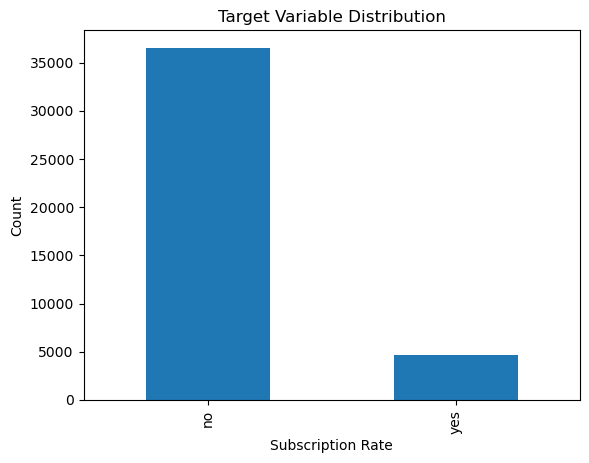

In [38]:
import matplotlib.pyplot as plt
class_distribution.plot(kind='bar')
plt.title("Target Variable Distribution")
plt.xlabel('Subscription Rate')
plt.ylabel('Count')

##### Assess class imbalance and discuss implications

Class imbalance could impact machine learning models implying that model may ignore the minority class (yes). It can predict "no" all the time and still get high accuracy.

Accuracy becomes misleading and unreliable.

Imbalance could result to poor detection of important cases, usually the "yes" class, making it difficult to identify potential customers.

##### --Calculate imbalance ratio and interpretation

In [41]:
imbalance_ratio=class_distribution['no']/class_distribution['yes']
print("Imbalance Ratio =", imbalance_ratio.round(2))

Imbalance Ratio = 7.88


The dataset is highly imbalanced with an imbalance ratio of approximately 7.88, indicating that non-subscribers significantly outnumber subscribers.

##### --What is the baseline success rate for the marketing campaign?

In [61]:
baseline_success_rate= df['y'].value_counts(normalize=True).max()*100 #(normalize turns count into percentage) 
print(f"Baseline Success Rate = {baseline_success_rate:.2f}")

Baseline Success Rate = 88.73


##### --How does class imbalance affect business decision-making?

Low subscription rate implies that the marketing strategy is inefficient. The company is most likely contacting a high amount of individuals with little success.

Imbalance hinders efficient resource allocation as target is placed on unlikely customers instead of high probability customers that improve target market.

It puts business at risk of wrong insight as accuracy becomes an unreliable metric and fails to find real customers.

#### 2. Univariate Analysis
##### 2.1 Numerical Variables
##### Research Questions:
* What is the distribution of the age variable? Are there any outliers?
* How are campaign, duration, pdays, and previous distributed?
* Which numerical variables show normal vs. skewed distributions?
##### Analysis Requirements:
* Generate descriptive statistics for all numerical variables
* Create histograms and box plots to identify distribution patterns
* Identify and quantify outliers using statistical methods
* Analyze distribution shapes (normal, skewed, bimodal, etc.)

##### 2.2 Categorical Variables
##### Research Questions:
* Which job category has the highest and lowest frequency?
* What are the most common marital statuses and education levels?
* How are contact methods and loan statuses distributed?

##### Analysis Requirements:
* Generate frequency tables for all categorical variables
* Create bar charts showing category distributions
* Identify dominant categories and rare occurrences
* Calculate percentages and cumulative frequencies

##### What is the distribution of the age variable? Are there any outliers?

In [70]:
df['age'].head()

0    56
1    57
2    37
3    40
4    56
Name: age, dtype: int64

In [62]:
df['age'].describe()

count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64

Text(0.5, 1.0, 'Age Distribution')

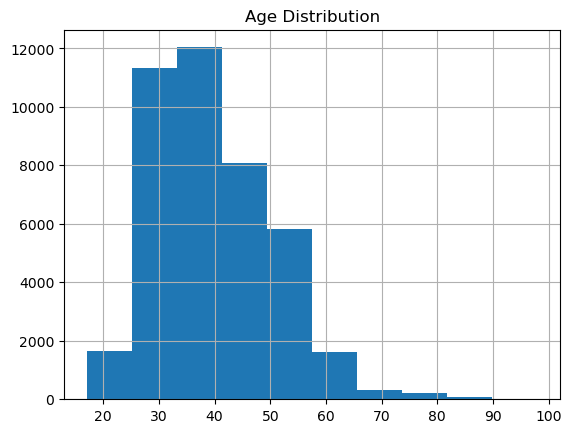

In [65]:
df['age'].hist()
plt.title("Age Distribution")

<Axes: >

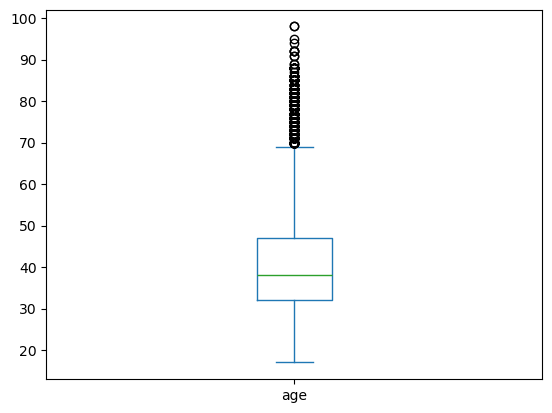

In [76]:
df['age'].plot(kind='box')

The above diagram indicates the presence of outliers.

In [119]:
# Detecting outliers using inter quantile range
Q1=df['age'].quantile(0.25)
Q3=df['age'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
age_outliers=df[(df['age']<lower)|(df['age']>upper)]

In [120]:
age_outliers['age']

27713    70
27757    76
27780    73
27800    88
27802    88
         ..
40986    84
40996    81
41004    80
41183    73
41187    74
Name: age, Length: 469, dtype: int64

##### How are campaign, duration, pdays, and previous distributed?


In [88]:
df.head(2)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Text(0.5, 1.0, 'Campaign Distribution')

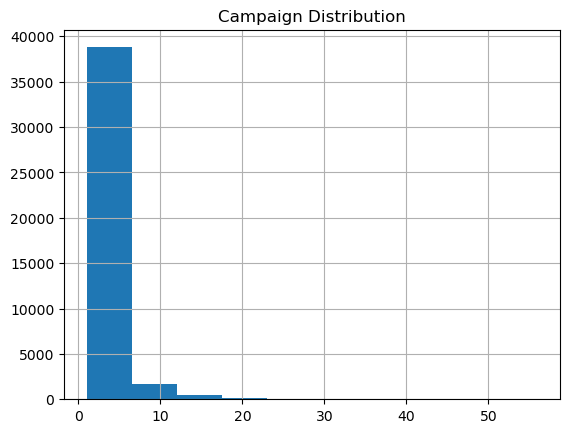

In [90]:
df['campaign'].hist()
plt.title("Campaign Distribution")

In [89]:
df['campaign'].describe()

count    41188.000000
mean         2.567593
std          2.770014
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

<Axes: >

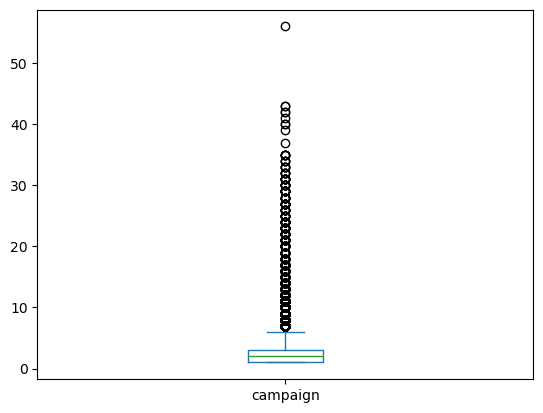

In [105]:
df['campaign'].plot(kind='box')

In [117]:
# Detecting outliers using inter quantile range
Q1=df['campaign'].quantile(0.25)
Q3=df['campaign'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
campaign_outliers=df[(df['campaign']<lower)|(df['campaign']>upper)]

In [118]:
campaign_outliers['campaign']

887      7
1043     8
1094     8
1097     7
1230     7
        ..
40611    9
40631    7
40698    7
40821    9
40993    7
Name: campaign, Length: 2406, dtype: int64

Text(0.5, 1.0, 'Duration Distribution')

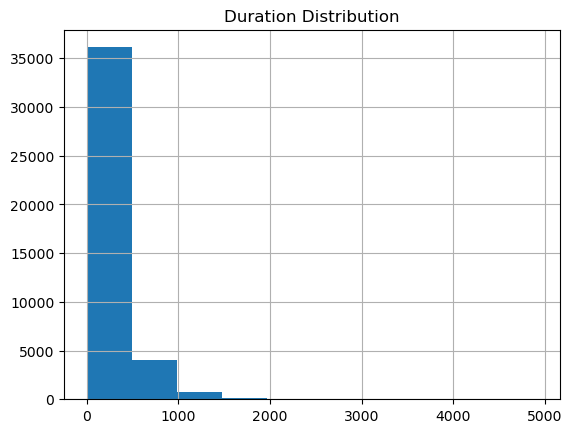

In [96]:
df['duration'].hist()
plt.title("Duration Distribution")

In [94]:
df['duration'].describe()

count    41188.000000
mean       258.285010
std        259.279249
min          0.000000
25%        102.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

<Axes: >

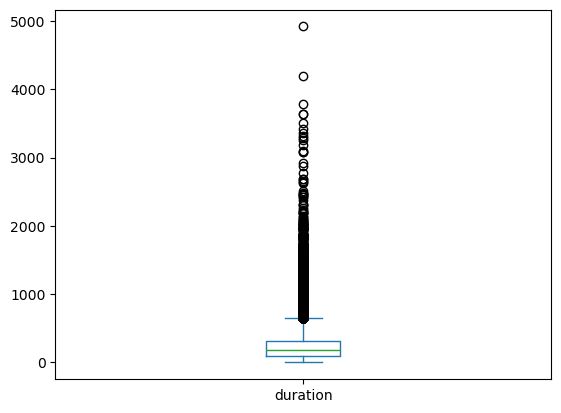

In [111]:
df['duration'].plot(kind='box')

In [113]:
# Detecting outliers using inter quantile range
Q1=df['duration'].quantile(0.25)
Q3=df['duration'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
duration_outliers=df[(df['duration']<lower)|(df['duration']>upper)]

In [115]:
duration_outliers['duration']

37       1666
57        787
61        812
75       1575
83       1042
         ... 
41147     712
41153     655
41160     843
41164    1868
41166     651
Name: duration, Length: 2963, dtype: int64

Text(0.5, 1.0, 'Pdays Distribution')

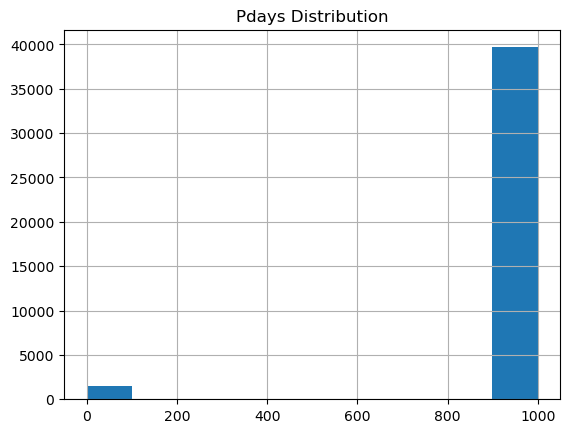

In [100]:
df['pdays'].hist()
plt.title("Pdays Distribution")

In [99]:
df['pdays'].describe()

count    41188.000000
mean       962.475454
std        186.910907
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: pdays, dtype: float64

<Axes: >

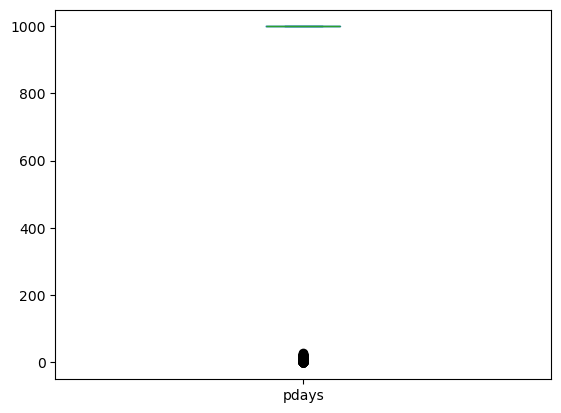

In [121]:
df['pdays'].plot(kind='box')

In [124]:
# Detecting outliers using inter quantile range
Q1=df['pdays'].quantile(0.25)
Q3=df['pdays'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
pdays_outliers=df[(df['pdays']<lower)|(df['pdays']>upper)]

In [125]:
pdays_outliers['pdays']

24108     6
24264     4
24279     4
24397     3
24482     4
         ..
41163     4
41164    10
41174     1
41178     6
41182     9
Name: pdays, Length: 1515, dtype: int64

Text(0.5, 1.0, 'Previous Distribution')

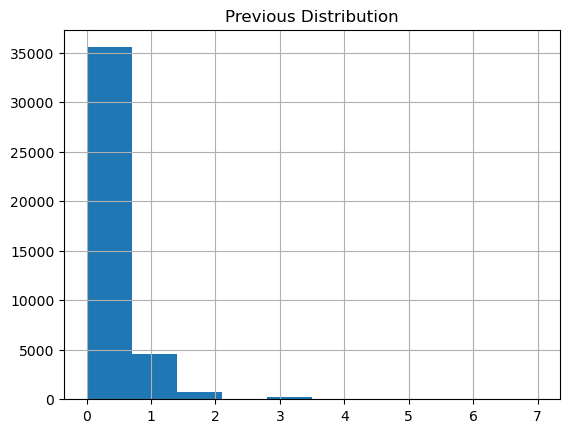

In [101]:
df['previous'].hist()
plt.title("Previous Distribution")

In [102]:
df['previous'].describe()

count    41188.000000
mean         0.172963
std          0.494901
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: previous, dtype: float64

<Axes: >

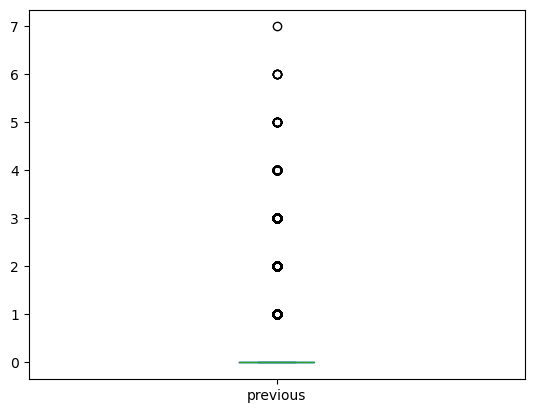

In [126]:
df['previous'].plot(kind='box')

In [127]:
# Detecting outliers using inter quantile range
Q1=df['previous'].quantile(0.25)
Q3=df['previous'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
previous_outliers=df[(df['previous']<lower)|(df['previous']>upper)]

In [128]:
previous_outliers['previous']

24013    1
24019    1
24076    1
24102    1
24108    1
        ..
41174    6
41175    2
41178    3
41182    1
41187    1
Name: previous, Length: 5625, dtype: int64

##### Which numerical variables show normal vs. skewed distributions?


In [103]:
df.skew(numeric_only=True)

age               0.784697
duration          3.263141
campaign          4.762507
pdays            -4.922190
previous          3.832042
emp.var.rate     -0.724096
cons.price.idx   -0.230888
cons.conf.idx     0.303180
euribor3m        -0.709188
nr.employed      -1.044262
dtype: float64

Variables such as "duration", "campaign", and "previous" are positively skewed. While "age" is closer to a normal distribution.

##### Analysis Requirements:
* Generate descriptive statistics for all numerical variables
* Create histograms and box plots to identify distribution patterns
* Identify and quantify outliers using statistical methods
* Analyze distribution shapes (normal, skewed, bimodal, etc.)

##### 2.2 Categorical Variables
##### Analysis Requirements:
* Generate frequency tables for all categorical variables
* Create bar charts showing category distributions
* Identify dominant categories and rare occurrences
* Calculate percentages and cumulative frequencies

In [131]:
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

In [137]:
print( df['job'].value_counts())
print('*'*30)
print()
print( df['marital'].value_counts())
print('*'*30)
print()
print( df['education'].value_counts())
print('*'*30)
print()
print( df['default'].value_counts())
print('*'*30)
print()
print( df['housing'].value_counts())
print('*'*30)
print()
print( df['loan'].value_counts())
print('*'*30)
print()
print( df['contact'].value_counts())

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
******************************

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
******************************

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64
******************************

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64
******************************

housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64
**********************

##### Create bar charts showing category distributions

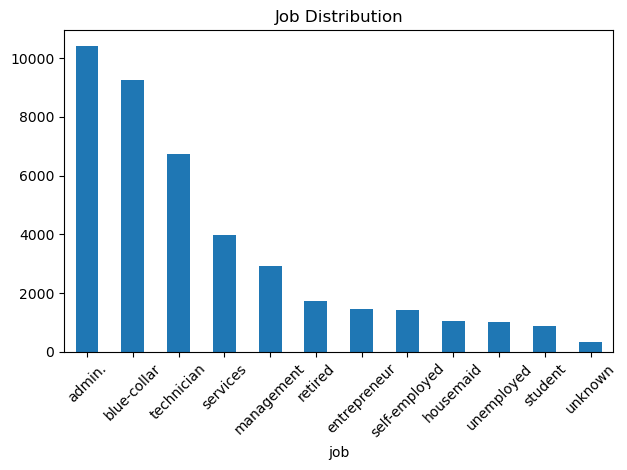

In [142]:
df['job'].value_counts().plot(kind='bar')
plt.title('Job Distribution')
plt.xticks(rotation=45)
plt.tight_layout()

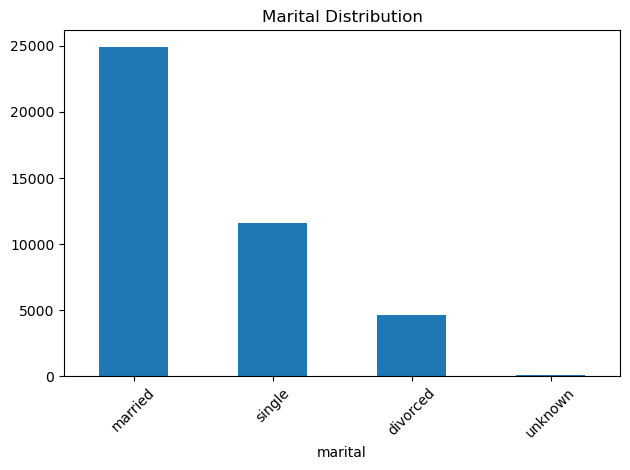

In [148]:
df['marital'].value_counts().plot(kind='bar')
plt.title("Marital Distribution")
plt.xticks(rotation=45)
plt.tight_layout()

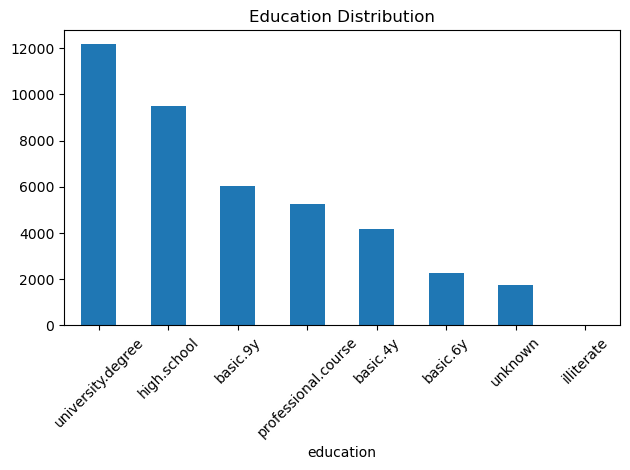

In [149]:
df['education'].value_counts().plot(kind='bar')
plt.title("Education Distribution")
plt.xticks(rotation=45)
plt.tight_layout()

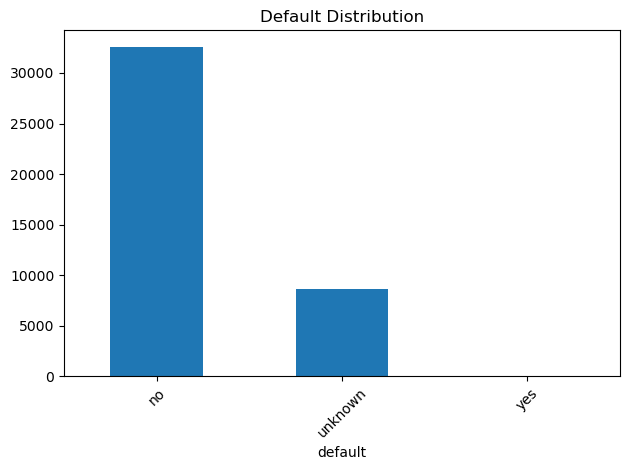

In [150]:
df['default'].value_counts().plot(kind='bar')
plt.title("Default Distribution")
plt.xticks(rotation=45)
plt.tight_layout()

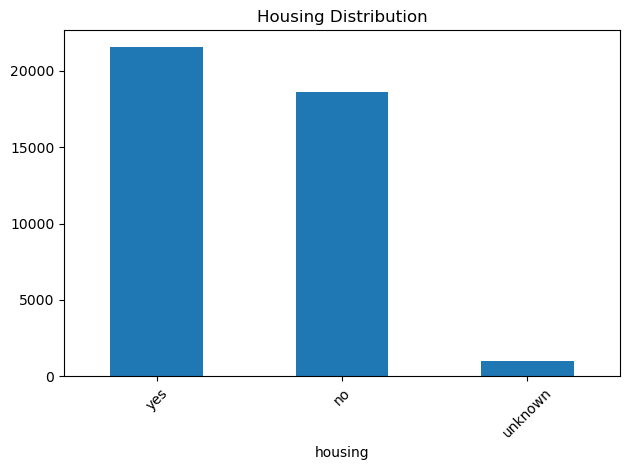

In [151]:
df['housing'].value_counts().plot(kind='bar')
plt.title("Housing Distribution")
plt.xticks(rotation=45)
plt.tight_layout()

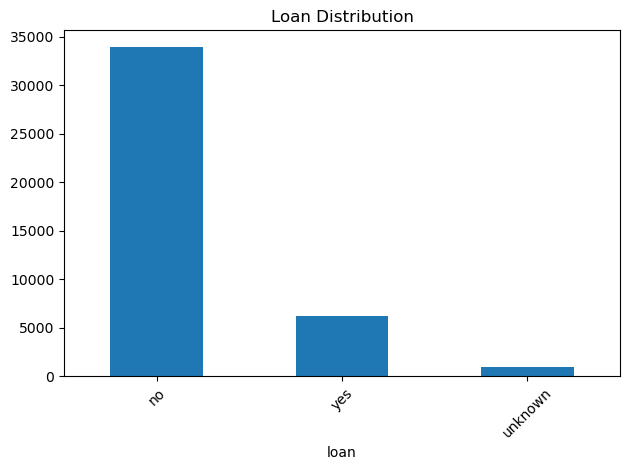

In [152]:
df['loan'].value_counts().plot(kind='bar')
plt.title("Loan Distribution")
plt.xticks(rotation=45)
plt.tight_layout()

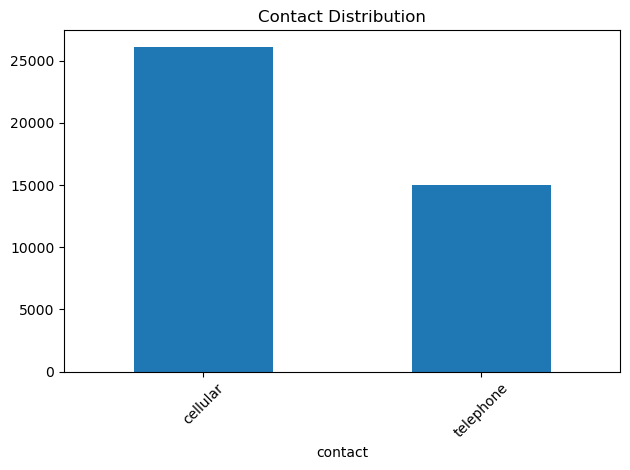

In [153]:
df['contact'].value_counts().plot(kind='bar')
plt.title("Contact Distribution")
plt.xticks(rotation=45)
plt.tight_layout()

##### Identify dominant categories and rare occurrences

In [204]:
def dominant_rare_occurrencies(freq):
    dominant=freq[freq>5]
    rare=freq[freq<1]
    normal=freq[(freq>=1)&(freq<=5)]
    return pd.DataFrame({
        "Dominant": dominant, 
        "Rare": rare, 
        "Normal": normal
    })

In [197]:
job_categories=df['job'].value_counts(normalize=True)*100
marital_categories=df['marital'].value_counts(normalize=True)*100
education_categories=df['education'].value_counts(normalize=True)*100
default_categories=df['default'].value_counts(normalize=True)*100
housing_categories=df['housing'].value_counts(normalize=True)*100
loan_categories=df['loan'].value_counts(normalize=True)*100
contact_categories=df['contact'].value_counts(normalize=True)*100

In [252]:
# Identifying dominant and rare categories
def dominant_category(distribution):
    dominant= dominant_rare_occurrencies(distribution)['Dominant'][~dominant_rare_occurrencies(distribution)['Dominant'].isnull()]
    return dominant 

def rare_category(distribution):
    rare=dominant_rare_occurrencies(distribution)['Rare'][~dominant_rare_occurrencies(distribution)['Rare'].isnull()]
    return rare

In [205]:
dominant_rare_occurrencies(job_categories)    

,Dominant,Rare,Normal
job,,,
admin.,25.303486,NaN,NaN
blue-collar,22.467709,NaN,NaN
entrepreneur,NaN,NaN,3.535010
housemaid,NaN,NaN,2.573565
management,7.099155,NaN,NaN
retired,NaN,NaN,4.175974
self-employed,NaN,NaN,3.450034
services,9.636302,NaN,NaN
student,NaN,NaN,2.124405


In [284]:
print (f"For Job Distribution, Dominant Categories include:\n\n{dominant_category(job_categories)}"
    f"\n\nRare Category include:\n\n{rare_category(job_categories)}")

For Job Distribution, Dominant Categories include:

job
admin.         25.303486
blue-collar    22.467709
management      7.099155
services        9.636302
technician     16.371273
Name: Dominant, dtype: float64

Rare Category include:

job
unknown    0.801204
Name: Rare, dtype: float64


In [206]:
dominant_rare_occurrencies(marital_categories)    

,Dominant,Rare,Normal
marital,,,
divorced,11.197436,NaN,NaN
married,60.522482,NaN,NaN
single,28.085850,NaN,NaN
unknown,NaN,0.194231,NaN


In [283]:
print (f"For Default Distribution, Marital Categories include:\n\n{dominant_category(marital_categories)}"
    f"\n\nRare Category include:\n\n{rare_category(marital_categories)}")

For Default Distribution, Marital Categories include:

marital
divorced    11.197436
married     60.522482
single      28.085850
Name: Dominant, dtype: float64

Rare Category include:

marital
unknown    0.194231
Name: Rare, dtype: float64


In [236]:
dominant_rare_occurrencies(education_categories)

,Dominant,Rare,Normal
education,,,
basic.4y,10.138875,NaN,NaN
basic.6y,5.564728,NaN,NaN
basic.9y,14.676605,NaN,NaN
high.school,23.101389,NaN,NaN
illiterate,NaN,0.043702,NaN
professional.course,12.729436,NaN,NaN
university.degree,29.542585,NaN,NaN
unknown,NaN,NaN,4.20268


In [282]:
print (f"For Education Distribution, Dominant Categories include:\n\n{dominant_category(education_categories)}"
    f"\n\nRare Category include:\n\n{rare_category(education_categories)}")

For Education Distribution, Dominant Categories include:

education
basic.4y               10.138875
basic.6y                5.564728
basic.9y               14.676605
high.school            23.101389
professional.course    12.729436
university.degree      29.542585
Name: Dominant, dtype: float64

Rare Category include:

education
illiterate    0.043702
Name: Rare, dtype: float64


In [238]:
dominant_rare_occurrencies(default_categories)    

,Dominant,Rare,Normal
default,,,
no,79.120132,NaN,NaN
unknown,20.872584,NaN,NaN
yes,NaN,0.007284,NaN


In [281]:
print (f"For Default Distribution, Dominant Categories include:\n\n{dominant_category(default_categories)}"
    f"\n\nRare Category include:\n\n{rare_category(default_categories)}")

For Default Distribution, Dominant Categories include:

default
no         79.120132
unknown    20.872584
Name: Dominant, dtype: float64

Rare Category include:

default
yes    0.007284
Name: Rare, dtype: float64


In [240]:
dominant_rare_occurrencies(housing_categories)    

,Dominant,Rare,Normal
housing,,,
no,45.212198,NaN,NaN
unknown,NaN,NaN,2.403613
yes,52.384190,NaN,NaN


In [280]:
print (f"For Housing Distribution, Dominant Categories include:\n\n{dominant_category(housing_categories)}"
    f"\n\nRare Category include:\n\n{rare_category(housing_categories)}")

For Housing Distribution, Dominant Categories include:

housing
no     45.212198
yes    52.384190
Name: Dominant, dtype: float64

Rare Category include:

Series([], Name: Rare, dtype: float64)


In [242]:
dominant_rare_occurrencies(loan_categories)    

,Dominant,Rare,Normal
loan,,,
no,82.426920,NaN,NaN
unknown,NaN,NaN,2.403613
yes,15.169467,NaN,NaN


In [278]:
print (f"For Loan Distribution, Dominant Categories include:\n\n{dominant_category(loan_categories)}"
    f"\n\nRare Category include:\n\n{rare_category(loan_categories)}")

For Loan Distribution, Dominant Categories include:

loan
no     82.426920
yes    15.169467
Name: Dominant, dtype: float64

Rare Category include:

Series([], Name: Rare, dtype: float64)


In [244]:
dominant_rare_occurrencies(contact_categories)    

,Dominant,Rare,Normal
contact,,,
cellular,63.474798,NaN,NaN
telephone,36.525202,NaN,NaN


In [276]:
print (f"For Contact Distribution, Dominant Categories include:\n\n{dominant_category(contact_categories)}"
    f"\n\nRare Category include:\n\n{rare_category(contact_categories)}")

For Contact Distribution, Dominant Categories include:

contact
cellular     63.474798
telephone    36.525202
Name: Dominant, dtype: float64

Rare Category include:

Series([], Name: Rare, dtype: float64)


For categorical variables, frequency analysis shows that certain categories dominate the dataset, while others are rare.

##### Calculate percentages and cumulative frequencies

In [258]:
def  percentages_cum_freq(variable):
    percentage=variable.value_counts(normalize=True)*100
    cum_freq=variable.value_counts().cumsum()
    return f"Percentage= {percentage}%\n\nCumulative Frequency= {cum_freq}" 

In [263]:
print(f"Percentage and Cummulative Frequency for Job Distribution\n\n{percentages_cum_freq(df['job'])}")

Percentage and Cummulative Frequency for Job Distribution

Percentage= job
admin.           25.303486
blue-collar      22.467709
technician       16.371273
services          9.636302
management        7.099155
retired           4.175974
entrepreneur      3.535010
self-employed     3.450034
housemaid         2.573565
unemployed        2.461882
student           2.124405
unknown           0.801204
Name: proportion, dtype: float64%

Cumulative Frequency= job
admin.           10422
blue-collar      19676
technician       26419
services         30388
management       33312
retired          35032
entrepreneur     36488
self-employed    37909
housemaid        38969
unemployed       39983
student          40858
unknown          41188
Name: count, dtype: int64


In [264]:
print(f"Percentage and Cummulative Frequency for Marital Distribution\n\n{percentages_cum_freq(df['marital'])}")

Percentage and Cummulative Frequency for Marital Distribution

Percentage= marital
married     60.522482
single      28.085850
divorced    11.197436
unknown      0.194231
Name: proportion, dtype: float64%

Cumulative Frequency= marital
married     24928
single      36496
divorced    41108
unknown     41188
Name: count, dtype: int64


In [266]:
print(f"Percentage and Cummulative Frequency for Education Distribution\n\n{percentages_cum_freq(df['education'])}")

Percentage and Cummulative Frequency for Education Distribution

Percentage= education
university.degree      29.542585
high.school            23.101389
basic.9y               14.676605
professional.course    12.729436
basic.4y               10.138875
basic.6y                5.564728
unknown                 4.202680
illiterate              0.043702
Name: proportion, dtype: float64%

Cumulative Frequency= education
university.degree      12168
high.school            21683
basic.9y               27728
professional.course    32971
basic.4y               37147
basic.6y               39439
unknown                41170
illiterate             41188
Name: count, dtype: int64


In [267]:
print(f"Percentage and Cummulative Frequency for Default Distribution\n\n{percentages_cum_freq(df['default'])}")

Percentage and Cummulative Frequency for Default Distribution

Percentage= default
no         79.120132
unknown    20.872584
yes         0.007284
Name: proportion, dtype: float64%

Cumulative Frequency= default
no         32588
unknown    41185
yes        41188
Name: count, dtype: int64


In [268]:
print(f"Percentage and Cummulative Frequency for Housing Distribution\n\n{percentages_cum_freq(df['housing'])}")

Percentage and Cummulative Frequency for Housing Distribution

Percentage= housing
yes        52.384190
no         45.212198
unknown     2.403613
Name: proportion, dtype: float64%

Cumulative Frequency= housing
yes        21576
no         40198
unknown    41188
Name: count, dtype: int64


In [269]:
print(f"Percentage and Cummulative Frequency for Loan Distribution\n\n{percentages_cum_freq(df['loan'])}")

Percentage and Cummulative Frequency for Loan Distribution

Percentage= loan
no         82.426920
yes        15.169467
unknown     2.403613
Name: proportion, dtype: float64%

Cumulative Frequency= loan
no         33950
yes        40198
unknown    41188
Name: count, dtype: int64


In [270]:
print(f"Percentage and Cummulative Frequency for Contact Distribution\n\n{percentages_cum_freq(df['contact'])}")

Percentage and Cummulative Frequency for Contact Distribution

Percentage= contact
cellular     63.474798
telephone    36.525202
Name: proportion, dtype: float64%

Cumulative Frequency= contact
cellular     26144
telephone    41188
Name: count, dtype: int64


##### Research Questions:
##### Which job category has the highest and lowest frequency?


In [296]:
highest_freq_index=df['job'].value_counts().idxmax()
highest_freq=df['job'].value_counts().max()
lowest_freq_index=df['job'].value_counts().idxmin()
lowest_freq=df['job'].value_counts().min()
print (f'Job category with highest frenquency= "{highest_freq_index}" with frequency of "{highest_freq}"'
       f'\n\nJob category with lowest frenquency= "{lowest_freq_index}" with frequency of "{lowest_freq}"')

Job category with highest frenquency= "admin." with frequency of "10422"

Job category with lowest frenquency= "unknown" with frequency of "330"


##### What are the most common marital statuses and education levels? 

In [312]:
marital_statuses=df['marital'].value_counts()
education_lvls=df['education'].value_counts()
print(f'Most common marital status: "{marital_statuses.idxmax()}" with "{marital_statuses.max()}" values.'
      f'\n\nMost common education level: {education_lvls.idxmax()} with "{education_lvls.max()}" values.')

Most common marital status: "married" with "24928" values.

Most common education level: university.degree with "12168" values.


##### How are contact methods and loan statuses distributed?

In [315]:
print (f'Contact methods distribution:\n{df['contact'].value_counts()}'
       f'\n\nLoan statuses distribution:\n{df['loan'].value_counts()}')

Contact methods distribution:
contact
cellular     26144
telephone    15044
Name: count, dtype: int64

Loan statuses distribution:
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64


#### 3. Bivariate Analysis
##### 3.1 Target vs. Categorical Features

##### Research Questions:
* How does subscription to a term deposit vary by job type?
* Is there a difference in subscription rates between married and single clients?
* Do education levels influence subscription likelihood?
* How do housing and personal loans affect subscription rates?

##### Analysis Requirements:
* Create cross-tabulations between target and categorical variables
* Calculate subscription rates by category
* Generate grouped bar charts and stacked plots
* Document observed patterns and relationships


##### How does subscription to a term deposit vary by job type?

In [376]:
job_sub_rates=pd.crosstab(df['job'],df['y'],normalize='index').round(2)*100
job_sub_rates

y,no,yes
job,,
admin.,87.0,13.0
blue-collar,93.0,7.0
entrepreneur,91.0,9.0
housemaid,90.0,10.0
management,89.0,11.0
retired,75.0,25.0
self-employed,90.0,10.0
services,92.0,8.0
student,69.0,31.0


Subscription rates vary significantly across job types. Some job categories like (students, retired, ) show higher subscription rates. The others show lower subscription rates. This suggests that job type influences financial decisions.

In [320]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


##### Is there a difference in subscription rates between married and single clients?

In [375]:
marital_sub_rates=pd.crosstab(df['marital'],df['y'],normalize='index').round(2)*100
marital_sub_rates

y,no,yes
marital,,
divorced,90.0,10.0
married,90.0,10.0
single,86.0,14.0
unknown,85.0,15.0


In [334]:
filtered_df=df[df['marital'].isin(['married','single'])]
pd.crosstab(filtered_df['marital'],filtered_df['y'],normalize='index').round(2)*100

y,no,yes
marital,,
married,90.0,10.0
single,86.0,14.0


There is a noticeable difference in subscription rates across marital statuses. Married clients have a subscription rate of '10%' while single clients have a subscription rate of '14%'

##### Do education levels influence subscription likelihood?

In [374]:
edu_sub_rates=pd.crosstab(df['education'],df['y'],normalize='index').round(2)*100
edu_sub_rates

y,no,yes
education,,
basic.4y,90.0,10.0
basic.6y,92.0,8.0
basic.9y,92.0,8.0
high.school,89.0,11.0
illiterate,78.0,22.0
professional.course,89.0,11.0
university.degree,86.0,14.0
unknown,85.0,15.0


While raw counts suggest higher subscriptions among certain education groups, this is due to differences in group sizes as seen below. After normalizing, subscription rates across education levels show that education levels do not totally influence subscription likelihood. However, higher education levels slightly show higher subscription rates.

In [348]:
# Group sizes for education
df['education'].value_counts()

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

##### How do housing and personal loans affect subscription rates?

In [401]:
housing_sub_rates=pd.crosstab(df['housing'],df['y'],normalize='index').round(2)*100
housing_sub_rates

y,no,yes
housing,,
no,89.0,11.0
unknown,89.0,11.0
yes,88.0,12.0


In [373]:
loan_sub_rates=pd.crosstab(df['loan'],df['y'],normalize='index').round(2)*100
loan_sub_rates

y,no,yes
loan,,
no,89.0,11.0
unknown,89.0,11.0
yes,89.0,11.0


Subscription rates are consistent across housing and personal loans. Clients with housing loan have a slightly higher subscription rate of 12% compared to 11% of those without. 

personal loans show consistent subscription rate of 11% across all clients.

This suggests that housing or personal loans do not influence a clients likelihood to subscribe.

##### Create cross-tabulations between target and categorical variables

In [362]:
def cross_tabs(variable):
    result=pd.crosstab(df[(variable)],df['y'])
    return result

###### Job Category

In [363]:
cross_tabs('job')

y,no,yes
job,,
admin.,9070,1352
blue-collar,8616,638
entrepreneur,1332,124
housemaid,954,106
management,2596,328
retired,1286,434
self-employed,1272,149
services,3646,323
student,600,275


###### Marital Category

In [366]:
cross_tabs('marital')

y,no,yes
marital,,
divorced,4136,476
married,22396,2532
single,9948,1620
unknown,68,12


###### Education Category

In [367]:
cross_tabs('education')

y,no,yes
education,,
basic.4y,3748,428
basic.6y,2104,188
basic.9y,5572,473
high.school,8484,1031
illiterate,14,4
professional.course,4648,595
university.degree,10498,1670
unknown,1480,251


###### Default Category

In [368]:
cross_tabs('default')

y,no,yes
default,,
no,28391,4197
unknown,8154,443
yes,3,0


###### Housing Category

In [369]:
cross_tabs('housing')

y,no,yes
housing,,
no,16596,2026
unknown,883,107
yes,19069,2507


###### Loan Category

In [370]:
cross_tabs('loan')

y,no,yes
loan,,
no,30100,3850
unknown,883,107
yes,5565,683


###### Contact Category

In [371]:
cross_tabs('contact')

y,no,yes
contact,,
cellular,22291,3853
telephone,14257,787


##### Calculate subscription rates by category

Subscription rates for "job", "marital", "education", "housing", and "loan"categories have been treated above.

Subscription rates for "default" category:

In [377]:
default_sub_rates=pd.crosstab(df['default'],df['y'],normalize='index').round(2)*100
default_sub_rates

y,no,yes
default,,
no,87.0,13.0
unknown,95.0,5.0
yes,100.0,0.0


In [379]:
contact_sub_rates=pd.crosstab(df['contact'],df['y'],normalize='index').round(2)*100
contact_sub_rates

y,no,yes
contact,,
cellular,85.0,15.0
telephone,95.0,5.0


##### Generate grouped bar charts and stacked plots

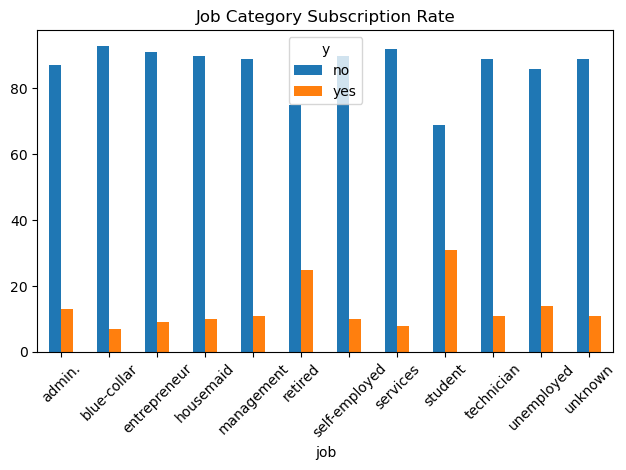

In [383]:
job_sub_rates.plot(kind='bar')
plt.title("Job Category Subscription Rate")
plt.xticks(rotation=45)
plt.tight_layout()

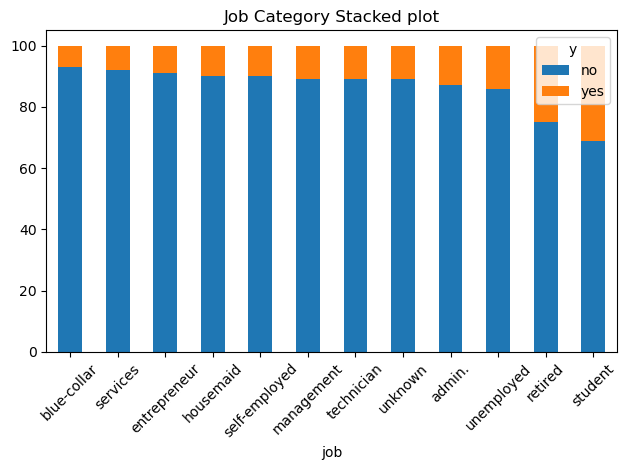

In [390]:
job_sub_rates.sort_values(by='yes').plot(kind='bar',stacked=True) # displays lowest to highest sub rates
plt.title("Job Category Stacked plot")
plt.xticks(rotation=45)
plt.tight_layout()

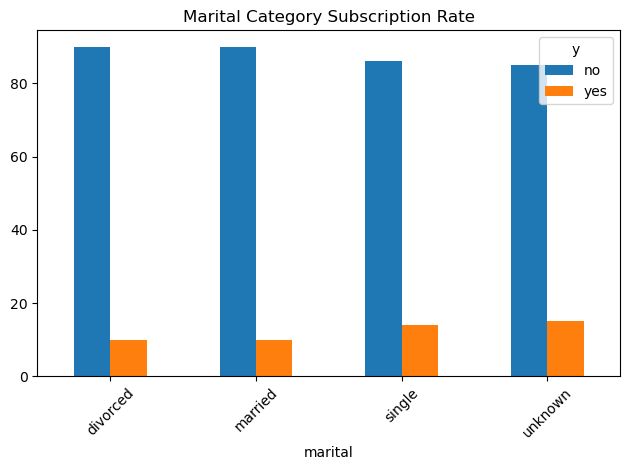

In [391]:
marital_sub_rates.plot(kind='bar')
plt.title("Marital Category Subscription Rate")
plt.xticks(rotation=45)
plt.tight_layout()

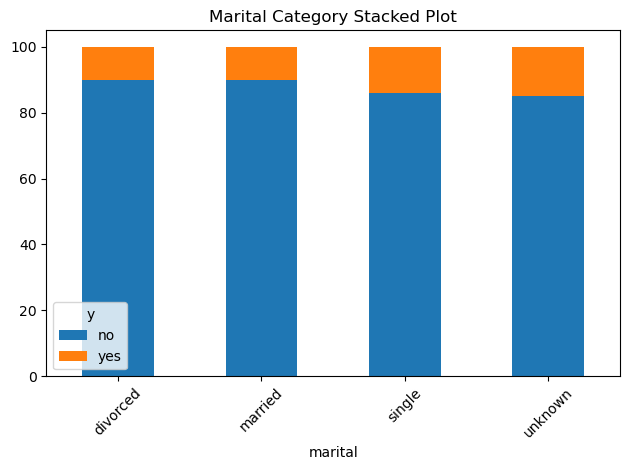

In [397]:
marital_sub_rates.sort_values(by='yes').plot(kind='bar', stacked=True)
plt.title("Marital Category Stacked Plot")
plt.xticks(rotation=45)
plt.tight_layout()

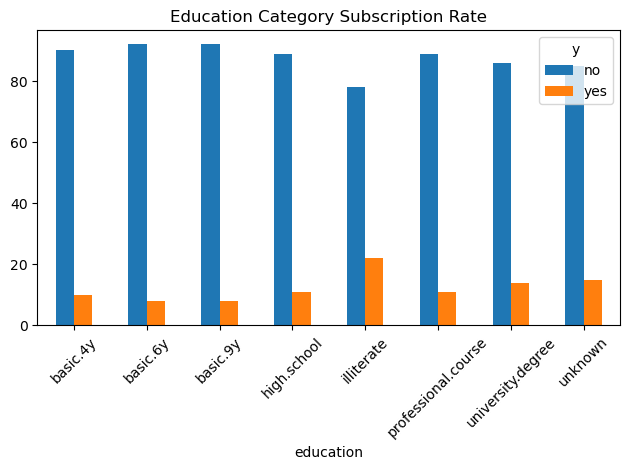

In [393]:
edu_sub_rates.plot(kind='bar')
plt.title("Education Category Subscription Rate")
plt.xticks(rotation=45)
plt.tight_layout()

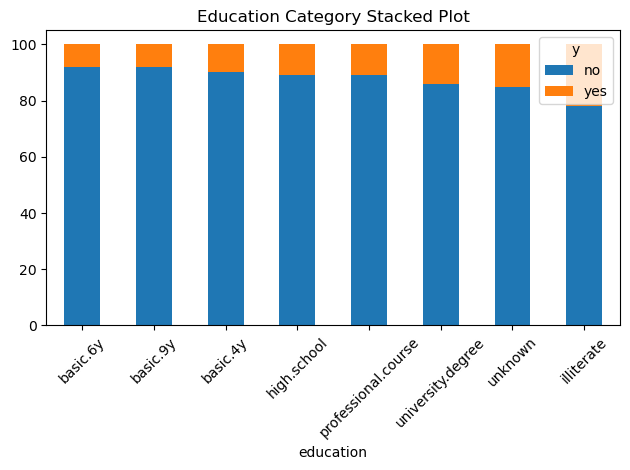

In [398]:
edu_sub_rates.sort_values(by='yes').plot(kind='bar', stacked=True)
plt.title("Education Category Stacked Plot")
plt.xticks(rotation=45)
plt.tight_layout()

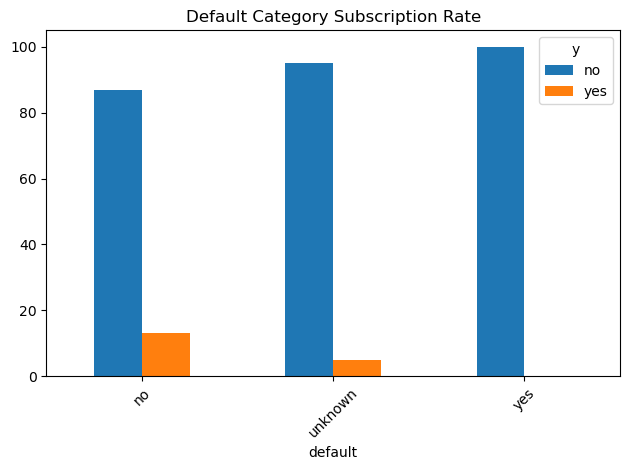

In [395]:
default_sub_rates.plot(kind='bar')
plt.title("Default Category Subscription Rate")
plt.xticks(rotation=45)
plt.tight_layout()

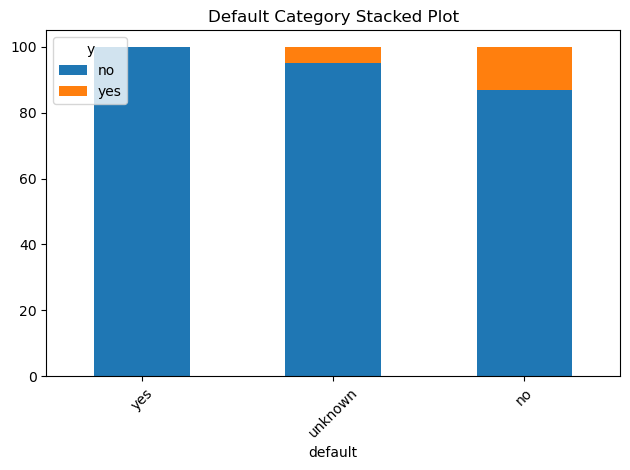

In [399]:
default_sub_rates.sort_values(by='yes').plot(kind='bar', stacked=True)
plt.title("Default Category Stacked Plot")
plt.xticks(rotation=45)
plt.tight_layout()

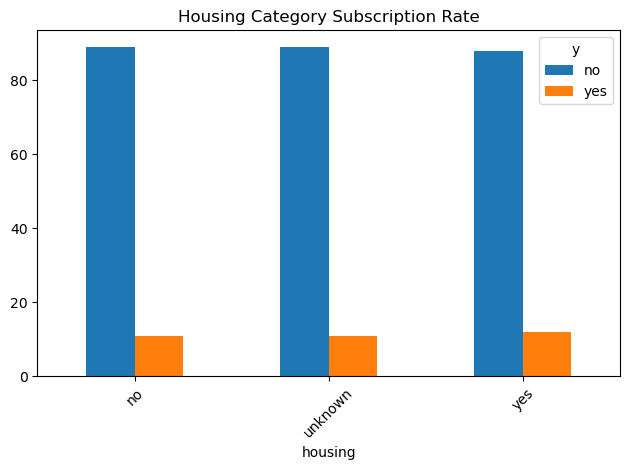

In [402]:
housing_sub_rates.plot(kind='bar')
plt.title("Housing Category Subscription Rate")
plt.xticks(rotation=45)
plt.tight_layout()

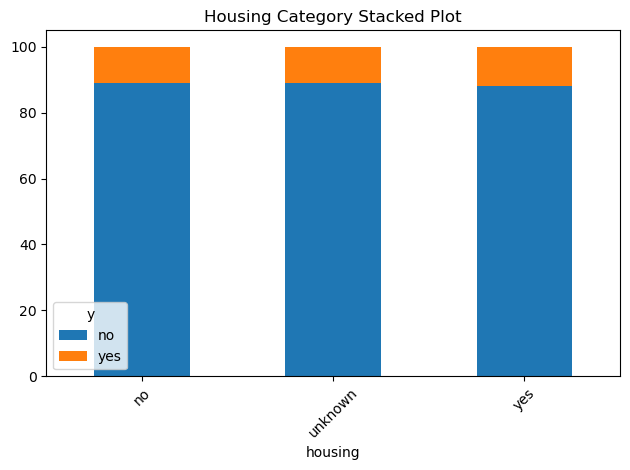

In [403]:
housing_sub_rates.sort_values(by='yes').plot(kind='bar', stacked=True)
plt.title("Housing Category Stacked Plot")
plt.xticks(rotation=45)
plt.tight_layout()

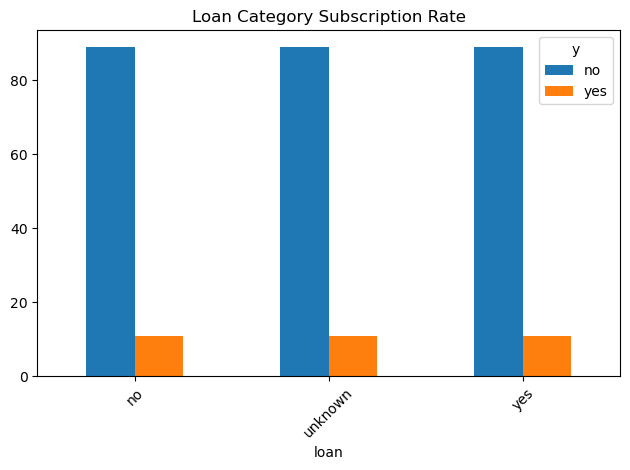

In [404]:
loan_sub_rates.plot(kind='bar')
plt.title("Loan Category Subscription Rate")
plt.xticks(rotation=45)
plt.tight_layout()

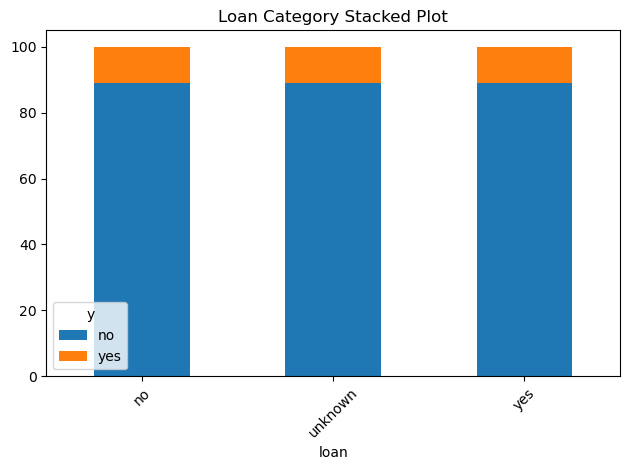

In [405]:
loan_sub_rates.sort_values(by='yes').plot(kind='bar', stacked=True)
plt.title("Loan Category Stacked Plot")
plt.xticks(rotation=45)
plt.tight_layout()

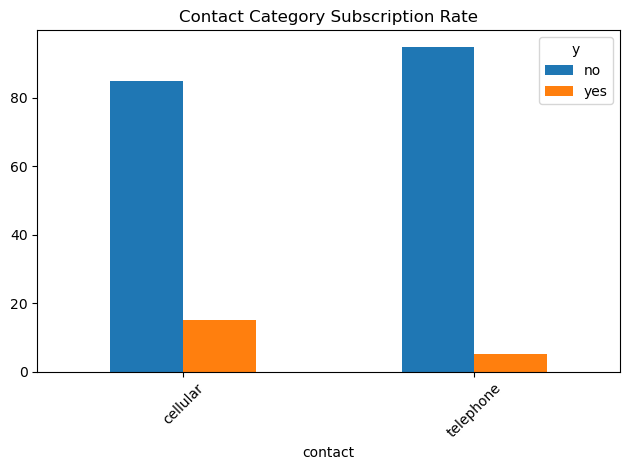

In [406]:
contact_sub_rates.plot(kind='bar')
plt.title("Contact Category Subscription Rate")
plt.xticks(rotation=45)
plt.tight_layout()

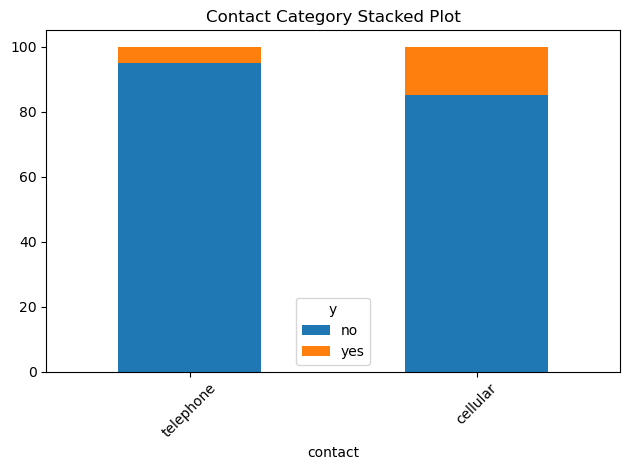

In [407]:
contact_sub_rates.sort_values(by='yes').plot(kind='bar', stacked=True)
plt.title("Contact Category Stacked Plot")
plt.xticks(rotation=45)
plt.tight_layout()

##### Document observed patterns and relationships

* Marital status impat decisions with single individuals generally more likely to subscribe probably due to lesser financial responsibilities.
* Education levels have slight positive correlation with subscription likelihood but does not entirely determine subscription rates.
* Financial obligations like housing and loans have consistent subscription rates amongst clients implying that they do not influence subscription rates.
* Subscription rates vary across job types. Students, retired and unemployed show higher subscription rates implying that individuals with little to no jobs are more likely to subscribe.

#### 3.2 Target vs. Numerical Features
##### Research Questions:
* Do clients who were previously contacted (previous > 0) tend to subscribe more often?
* How does campaign duration affect subscription rates?
* Is there an optimal age range for term deposit subscriptions?
* How do economic indicators relate to subscription success?

##### Analysis Requirements:
* Compare numerical feature distributions between subscribers and non-subscribers
* Create box plots and violin plots for group comparisons
* Calculate correlation coefficients with target variable
* Document observable differences and patterns

##### Do clients who were previously contacted (previous > 0) tend to subscribe more often?

In [422]:
df.groupby(df['previous']>0)['y'].value_counts(normalize=True).round(2)*100

previous  y  
False     no     91.0
          yes     9.0
True      no     73.0
          yes    27.0
Name: proportion, dtype: float64

Yes, clients who were previously contacted tend to subscribe 3 times more than clients who were not with percentage 27 vs 9%.

##### How does campaign duration affect subscription rates?

In [427]:
df.groupby('y')['duration'].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,36548.0,220.844807,207.096293,0.0,95.0,163.5,279.00,4918.0
yes,4640.0,553.191164,401.171871,37.0,253.0,449.0,741.25,4199.0


In [645]:
df.groupby('y')['duration'].median()

y
0    163.5
1    449.0
Name: duration, dtype: float64

The median call duration for subscribing clients is significantly higher than those who did not subscribe. This indicates that c
lients who subscribe consistently have longer call durations, suggesting higher engagement increases subscription likelihood.

<Axes: title={'center': 'duration'}, xlabel='y'>

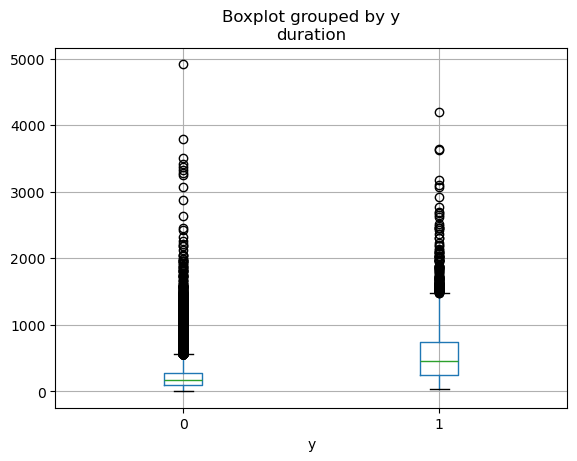

In [644]:
df.boxplot(column='duration', by='y')  

The boxplot shows a strong relationship between duration and subscription rate.

##### Is there an optimal age range for term deposit subscriptions?

<Axes: title={'center': 'age'}, xlabel='y'>

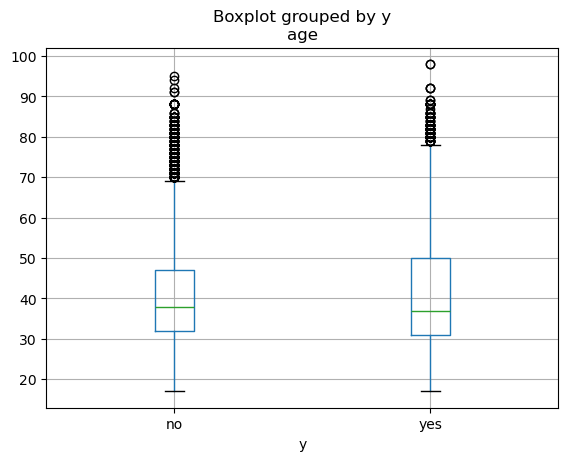

In [437]:
df.boxplot(column='age', by='y')  

Boxplot analysis show that middle_aged clients, ages 30-50 tend to subscribe more.

##### How do economic indicators relate to subscription success?

In [440]:
df.corr(numeric_only=True)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


Positive correlation increase subscription likelihood, negative correlation reduce likelihood.

##### Compare numerical feature distributions between subscribers and non-subscribers

In [656]:
df.groupby('y')[['age', 'duration', 'campaign', 'pdays', 'previous']].median()

,age,duration,campaign,pdays,previous
y,,,,,
0,38.0,163.5,2.0,999.0,0.0
1,37.0,449.0,2.0,999.0,0.0


##### Create box plots and violin plots for group comparisons

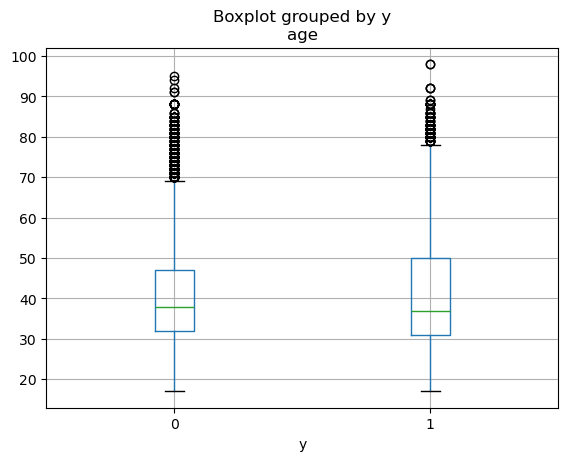

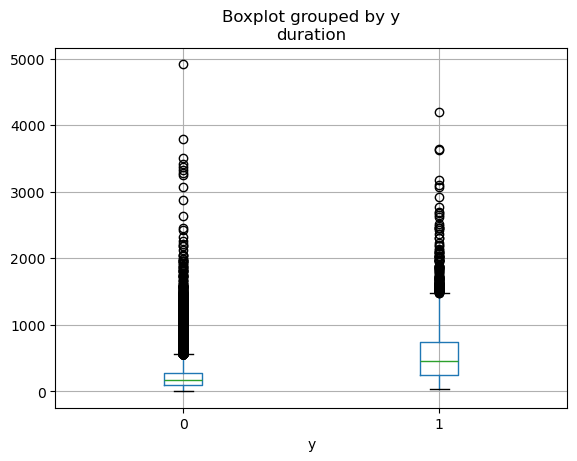

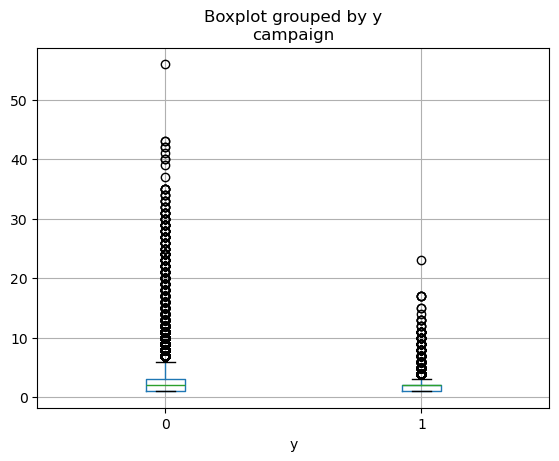

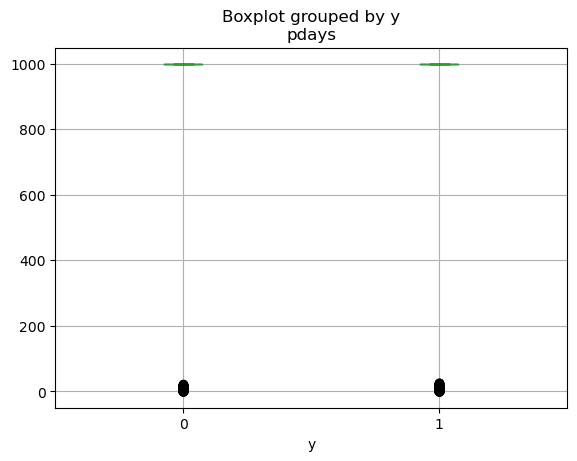

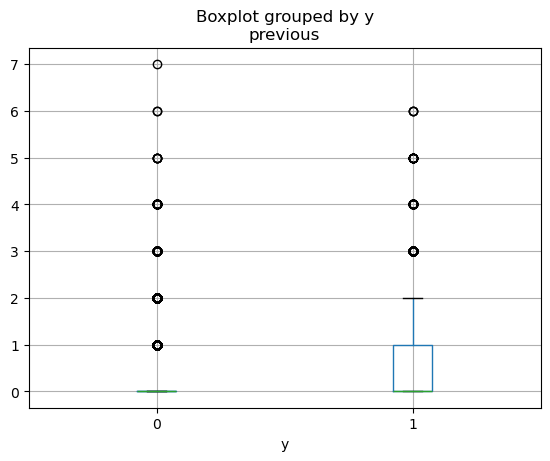

In [671]:
num_cols=df[['age', 'duration', 'campaign', 'pdays', 'previous']]
for col in num_cols:
    plt.show(df.boxplot(column=col, by='y'))

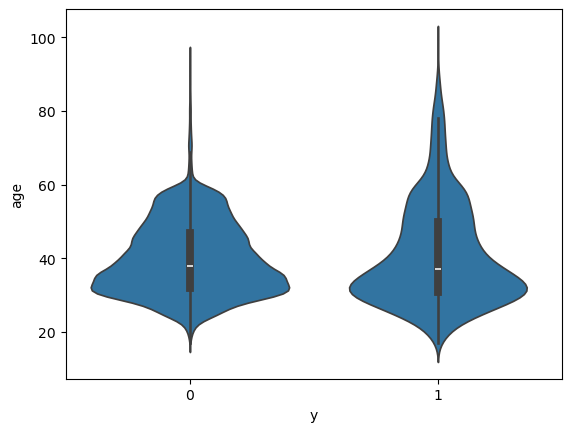

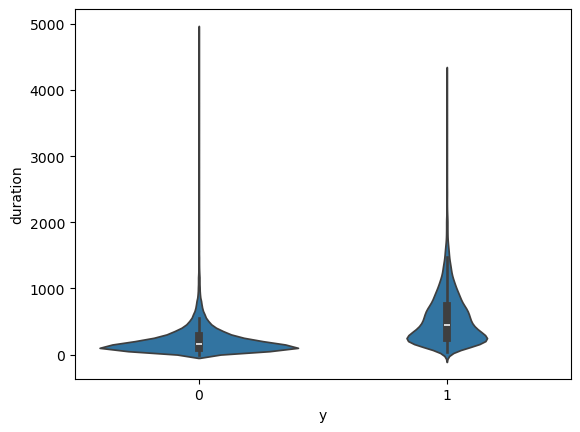

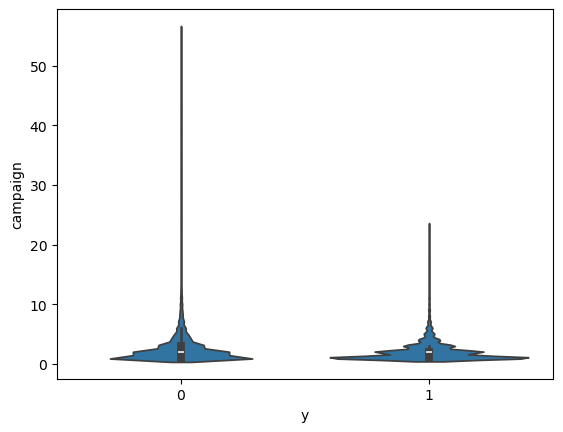

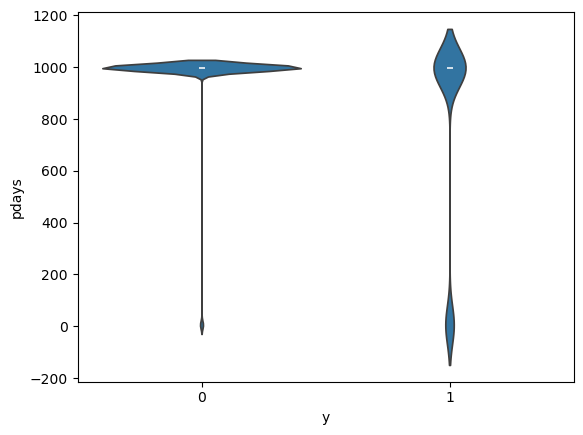

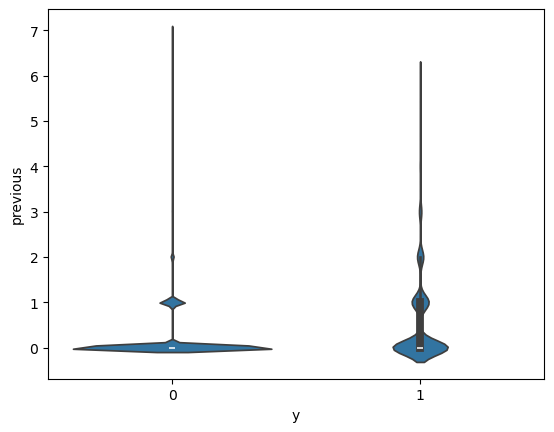

In [670]:
import seaborn as sns
num_cols=df[['age', 'duration', 'campaign', 'pdays', 'previous']]
for col in num_cols:
    plt.show(sns.violinplot(x='y', y=col, data=df))

##### Calculate correlation coefficients with target variable

In [672]:
df.corr(numeric_only=True)['y'].sort_values()

nr.employed      -0.354678
pdays            -0.324914
euribor3m        -0.307771
emp.var.rate     -0.298334
cons.price.idx   -0.136211
campaign         -0.066357
job_unknown      -0.000151
age               0.030399
cons.conf.idx     0.054878
previous          0.230181
duration          0.405274
y                 1.000000
y_encoded         1.000000
Name: y, dtype: float64

##### Document observable differences and patterns

* Clients with previous contact show a higher subscription rate, suggesting follow-up campaigns are effective.
* Campaign duration has strong positive relationship with subscription, indicating engagement is critical.
* Age shows moderate variation, with middle aged clients more likely to subscribe.
* Economic indicators show weak but noticeable correlations, suggesting external factors slightly influence decisions.

#### 4. Multivariate Analysis
##### 4.1 Feature Correlations
##### Research Questions:
* Which numerical features are strongly correlated with each other?
* Are there any multicollinearity concerns?
* How do economic indicators correlate with campaign success?
##### Analysis Requirements:
* Calculate correlation matrix for all numerical variables
* Create heatmap visualization of correlations
* Identify highly correlated feature pairs (|r| > 0.7)
* Analyze correlation patterns and business implications

##### Which numerical features are strongly correlated with each other?

In [674]:
nuum_cols=df.select_dtypes(include=['int64','float64']).columns
corr_matrix=df[nuum_cols].corr()
corr_matrix

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,y_encoded
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725,0.030399,0.030399
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703,0.405274,0.405274
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095,-0.066357,-0.066357
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605,-0.324914,-0.324914
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333,0.230181,0.230181
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970,-0.298334,-0.298334
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034,-0.136211,-0.136211
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513,0.054878,0.054878
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154,-0.307771,-0.307771
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000,-0.354678,-0.354678


Text(0.5, 1.0, 'Correlation Matrix')

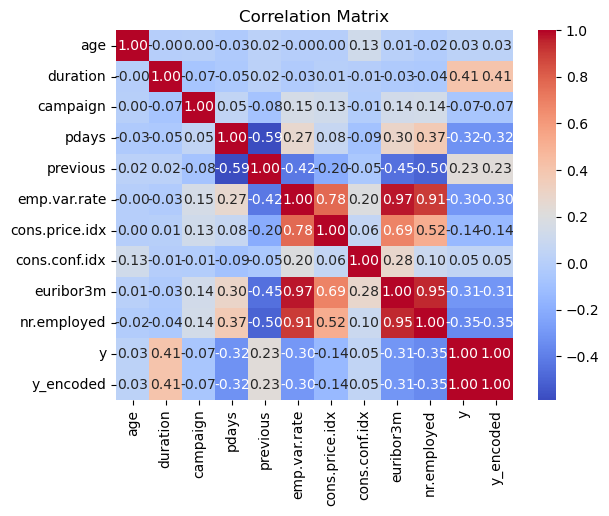

In [675]:
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')

* 0.7 to 1.0 implies a 'strong positive' correlation
* -0.7 to -1.0 implies 'strong negative' correlation
* 0.3 to 0.7 implies 'moderate' correlation
* 0 to o.3 implies 'weak' correlation.

##### Are there any multicollinearity concerns?

Multicollinearity refers to highly correlated features. correlation greater than 0.7 are said to be highly correlated.
Economic indicators exhibit srong correlations with each other suggesting the presence of multicollinearity as thes features capture similar underlying economic trends.

##### How do economic indicators correlate with campaign success?

In [677]:
target_corr=df.corr(numeric_only=True)['y'].sort_values()
target_corr

nr.employed      -0.354678
pdays            -0.324914
euribor3m        -0.307771
emp.var.rate     -0.298334
cons.price.idx   -0.136211
campaign         -0.066357
job_unknown      -0.000151
age               0.030399
cons.conf.idx     0.054878
previous          0.230181
duration          0.405274
y                 1.000000
y_encoded         1.000000
Name: y, dtype: float64

Economic indicators show negative correlation suggesting that when economy is strong, there's fewer subscription and when economy is weak, increased subscriptions.

##### Analyze correlation patterns and business implications

* Analysis show strong correlation among economic indicators suggesting that these variables move together and reflect the same underlying economic conditions. Business implication suggests redundant economic indicators. Since economic indicators provide similar information, use one key indicator instead of many. This can simplify dashbooards and models.
* There's weak correlation among customer features: age, campaign, previous, etc suggesting that these features have limited linear influence on subscription outcome. Therefore mass targeting based on demoographics is ineffective. Business should focus more on behavioral data than static attributes.
* Strong positive correlation exists between duration and subscription implying that longer calls are largely associated with successful subscriptions. Sales success is dependent on customer engagement quality. Business should train agents to keep meaningful converstions and focus on customer needs.
* Negative correlations exist between economic indicators and target variable suggesting that better economic conditions may reduce customer interest in term deposits. Campaign success is dependent on timing.
* In the case  multicollinearity, strong correlations exist among predictors suggesting that moodels may become unstablle or misleading.

#### 4.2 Complex Relationships
##### Research Questions:
* How do multiple categorical variables interact to influence subscriptions?
* What are the combined effects of age, job, and education on subscription rates?
##### Analysis Requirements:
* Create pivot tables for multi-dimensional analysis
* Generate grouped visualizations showing multiple variable relationships
* Identify interaction effects between variables

##### How do multiple categorical variables interact to influence subscriptions?

##### What are the combined effects of age, job, and education on subscription rates?

In [678]:
multi_var=pd.pivot_table(
    df,
    values='y',
    index=['age','job'],
    columns='education',
    aggfunc='mean'
)
multi_var

education         Unknown  basic.4y  basic.6y  basic.9y  high.school  \
age job                                                                
17  student      0.500000       NaN       NaN  0.333333          NaN   
18  student      0.461538  0.250000       0.5  0.500000         0.40   
19  student      0.529412  0.666667       1.0  0.285714         0.25   
20  admin.            NaN       NaN       NaN       NaN         0.00   
    blue-collar       NaN  0.000000       NaN  0.000000         0.00   
...                   ...       ...       ...       ...          ...   
91  retired           NaN       NaN       NaN       NaN          NaN   
92  retired      0.750000       NaN       NaN       NaN          NaN   
94  retired           NaN       NaN       NaN  0.000000          NaN   
95  retired           NaN       NaN       0.0       NaN          NaN   
98  retired           NaN  1.000000       NaN       NaN          NaN   

education        illiterate  professional.course  university.degree  
age job                                                              
17  student             NaN                  NaN                NaN  
18  student             NaN                  NaN                NaN  
19  student             NaN                  NaN                NaN  
20  admin.              NaN                  NaN                NaN  
    blue-collar         NaN                  NaN                NaN  
...                     ...                  ...                ...  
91  retired             NaN                  NaN                0.0  
92  retired             NaN                  NaN                NaN  
94  retired             NaN                  NaN                NaN  
95  retired             NaN                  NaN                NaN  
98  retired             NaN                  NaN                NaN  

[577 rows x 8 columns]

##### Create pivot tables for multi-dimensional analysis

In [680]:
# job x edu vs subscription
job_edu=pd.pivot_table(
    df,
    values='y',
    index='job',
    columns='education',
    aggfunc='mean'
)
job_edu

education,Unknown,basic.4y,basic.6y,basic.9y,high.school,illiterate,professional.course,university.degree
job,,,,,,,,
Unknown,0.129771,0.076923,0.045455,0.032258,0.054054,NaN,0.083333,0.244444
admin.,0.152610,0.129870,0.052980,0.084168,0.114749,0.000000,0.134986,0.143056
blue-collar,0.052863,0.053063,0.075035,0.066243,0.107062,0.000000,0.090508,0.095745
entrepreneur,0.070175,0.051095,0.126761,0.057143,0.068376,0.500000,0.066667,0.108197
housemaid,0.119048,0.107595,0.064935,0.031915,0.080460,0.000000,0.186441,0.122302
management,0.162602,0.050000,0.117647,0.066265,0.057047,NaN,0.089888,0.124576
retired,0.336735,0.309883,0.133333,0.131034,0.224638,0.666667,0.236515,0.231579
self-employed,0.068966,0.032258,0.040000,0.081818,0.067797,0.333333,0.119048,0.125490
services,0.126667,0.053030,0.088496,0.074742,0.075690,NaN,0.087156,0.150289


In [685]:
# Age x job
#creating age groups
df['age_group']=pd.cut(
    df['age'],
    bins=[0,30,50,100],
    labels=['Young','Middle','Senior']
)
age_job=pd.pivot_table(
    df,
    values='y',
    index='age_group',
    columns='job',
    aggfunc='mean',
    observed=False
)
age_job

job,Unknown,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed
age_group,,,,,,,,,,,,
Young,0.272727,0.171482,0.081154,0.101449,0.084746,0.146617,0.000000,0.153846,0.099454,0.331522,0.135622,0.207101
Middle,0.064171,0.111933,0.063869,0.082932,0.067797,0.100050,0.068376,0.098468,0.077987,0.223022,0.100021,0.120116
Senior,0.145455,0.158233,0.081037,0.085409,0.161932,0.134529,0.266583,0.076923,0.064302,NaN,0.116806,0.168831


##### Generate grouped visualizations showing multiple variable relationships

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

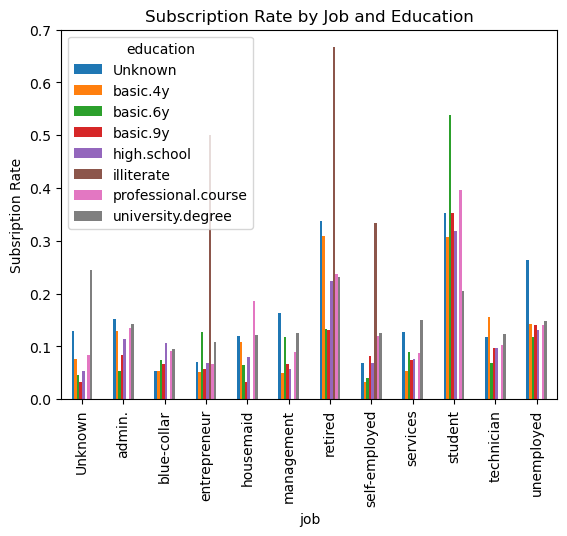

In [686]:
job_edu.plot(kind='bar')
plt.title('Subscription Rate by Job and Education')
plt.ylabel('Subsription Rate')
plt.tight_layout

Text(0, 0.5, 'Subsription Rate')

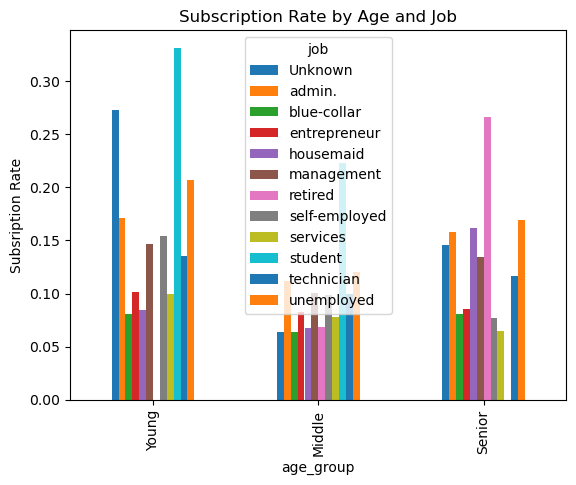

In [684]:
age_job.plot(kind='bar')
plt.title('Subscription Rate by Age and Job')
plt.ylabel('Subsription Rate')

##### Identify interaction effects between variables

The analysis reveals strong interaction effects between variables. The influence of age on subscription is not independent but varies by job type. For instance , young individuals show high subscription rates only when they are students, while senior individuals show high subscription rates primarily among retired customers. 

Similarly, education impacts subscription rates differently across job categories, with strong effects observed among students but minimal influence among blue-collar workers. 

These findings indicate that customer behaviour is driven by combined demographic factors rather than individual variables, highlighting the importance of segmented marketing strategies (splitting market into groups with similar characteristics and tailoring campaign strategy to each group instead of using same campaign strategy on everyone).

### Section B: Data Cleaning
##### 1. Handling Unknown Values
##### 1.1 Missing Data Assessment
##### Research Questions:
* Which columns contain the value 'unknown'? How many such entries exist in each?
* What percentage of data is missing for each affected column?
* Are missing values randomly distributed or systematically biased?

##### Analysis Requirements:
* Systematically identify all 'unknown' values across dataset
* Calculate missing data percentages by column
* Analyze patterns in missing data distribution
* Assess impact of missing data on analysis reliability

##### Which columns contain the value 'unknown'? How many such entries exist in each?

In [464]:
unknown_count=df.select_dtypes(include='object').apply(lambda x: (x=='unknown').sum())
unknown_counts=unknown_count[unknown_count>0]
unknown_counts

job           330
marital        80
education    1731
default      8597
housing       990
loan          990
dtype: int64

In [447]:
type(df)

pandas.core.frame.DataFrame

##### What percentage of data is missing for each affected column?

In [465]:
unknown_percentage=(unknown_counts/len(df))*100
round(unknown_percentage,2)

job           0.80
marital       0.19
education     4.20
default      20.87
housing       2.40
loan          2.40
dtype: float64

##### Are missing values randomly distributed or systematically biased?

In [468]:
df['job_unknown']=(df['job']=='unknown')
df['job_unknown']

0        False
1        False
2        False
3        False
4        False
         ...  
41183    False
41184    False
41185    False
41186    False
41187    False
Name: job_unknown, Length: 41188, dtype: bool

In [471]:
df.groupby('job_unknown')['y'].value_counts(normalize=True)

job_unknown  y
False        0    0.887342
             1    0.112658
True         0    0.887879
             1    0.112121
Name: proportion, dtype: float64

In [485]:
def unknown(variable):
    unknown=(df[(variable)]=='unknown')
    result=df.groupby(unknown)['y'].value_counts(normalize=True)
    return f'{unknown} \n\nKnown vs Unknown:{result}'

In [486]:
print(unknown('education'))

0        False
1        False
2        False
3        False
4        False
         ...  
41183    False
41184    False
41185    False
41186    False
41187    False
Name: education, Length: 41188, dtype: bool 

Known vs Unknown:education  y
False      0    0.888765
           1    0.111235
True       0    0.854997
           1    0.145003
Name: proportion, dtype: float64


In [487]:
print(unknown('marital'))

0        False
1        False
2        False
3        False
4        False
         ...  
41183    False
41184    False
41185    False
41186    False
41187    False
Name: marital, Length: 41188, dtype: bool 

Known vs Unknown:marital  y
False    0    0.887419
         1    0.112581
True     0    0.850000
         1    0.150000
Name: proportion, dtype: float64


In [488]:
print(unknown('default'))

0        False
1         True
2        False
3        False
4        False
         ...  
41183    False
41184    False
41185    False
41186    False
41187    False
Name: default, Length: 41188, dtype: bool 

Known vs Unknown:default  y
False    0    0.871222
         1    0.128778
True     0    0.948470
         1    0.051530
Name: proportion, dtype: float64


In [489]:
print(unknown('housing'))

0        False
1        False
2        False
3        False
4        False
         ...  
41183    False
41184    False
41185    False
41186    False
41187    False
Name: housing, Length: 41188, dtype: bool 

Known vs Unknown:housing  y
False    0    0.887233
         1    0.112767
True     0    0.891919
         1    0.108081
Name: proportion, dtype: float64


In [490]:
print(unknown('loan'))

0        False
1        False
2        False
3        False
4        False
         ...  
41183    False
41184    False
41185    False
41186    False
41187    False
Name: loan, Length: 41188, dtype: bool 

Known vs Unknown:loan   y
False  0    0.887233
       1    0.112767
True   0    0.891919
       1    0.108081
Name: proportion, dtype: float64


Analysis show that missing values represented as "unknown" are relatively consistent in subscription rates compared to known categories suggesting that missing data may be randomly distributed and without bias. However, demographics like marital and education show noticeable variation in subscription rates compared to known categories indicating systematic bias and suggesting that missing values may be due to underlying client characteristics.

##### Analyze patterns in missing data distribution
##### Assess impact of missing data on analysis reliability

In [497]:
missing_summary=pd.DataFrame({
    'Counts':unknown_counts, 
    "Percentage":round(unknown_percentage,2)
})
missing_summary

,Counts,Percentage
job,330,0.80
marital,80,0.19
education,1731,4.20
default,8597,20.87
housing,990,2.40
loan,990,2.40


In [498]:
missing_summary.sort_values(by='Percentage', ascending=False)

,Counts,Percentage
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


High missing percentages as seen in the demographic "default" implies weak conclusions, could be misleading and reduces reliability.

low missing percentages however do not significantly distort results.

#### 1.2 Missing Data Strategy
##### Research Questions:
* What strategy would you apply to handle these 'unknown' values?
* Should missing values be imputed, dropped, or treated as a separate category?
* How do different handling strategies affect data distribution?
##### Analysis Requirements:
* Evaluate multiple strategies for handling missing data
* Justify chosen approach based on data characteristics and business context
* Implement chosen strategy and document impact
* Compare before/after distributions


##### What strategy would you apply to handle these 'unknown' values?

"Unknown" values would be handled as a separate category to preserve information.

##### Should missing values be imputed, dropped, or treated as a separate category?
##### How do different handling strategies affect data distribution?

Missing values should be treated based on data characteristics.

Dropping missing values would reduce dataset size and potentially introduce bias. Imputation methods complete data, ensure minimal distortion but hides real patterns and introduces bias. Treating missing values as a separate category preserves real-world uncertainties, maintains distribution and captures behavioural differences.
However, all 3 strategies should be considered when handling missing values as determining the best approach is largely dependent on data type, missing pattern and business context.

In this case, missing values would be treated as separate category.

##### Justify chosen approach based on data characteristics and business context

Since missing values are mostly categorical variables, and represent meaningful absence of information, treating as separate category would preserve these information and avoid bias.

##### Implement chosen strategy and document impact

##### Treating as Separate category

In [508]:
df['job']=df['job'].replace('unknown', 'Unknown')
df['education']=df['education'].replace('unknown', 'Unknown')
df['marital']=df['marital'].replace('unknown', 'Unknown')
df['default']=df['default'].replace('unknown', 'Unknown')
df['housing']=df['housing'].replace('unknown', 'Unknown')
df['loan']=df['loan'].replace('unknown', 'Unknown')

The method preserves meaningful information, prevents distortion and potential bias.

##### Compare before/after distributions

In [509]:
df['job'].value_counts(normalize=True)

job
admin.           0.253035
blue-collar      0.224677
technician       0.163713
services         0.096363
management       0.070992
retired          0.041760
entrepreneur     0.035350
self-employed    0.034500
housemaid        0.025736
unemployed       0.024619
student          0.021244
Unknown          0.008012
Name: proportion, dtype: float64

Unknown appears the same. 

#### 2. Outlier Detection and Treatment
##### 2.1 Outlier Identification
##### Research Questions:
* Are there any outliers in the campaign, pdays, or previous columns?
* Which statistical methods are most appropriate for outlier detection?
* Do outliers represent data errors or legitimate extreme values?
##### Analysis Requirements:
* Apply descriptive outlier detection methods (IQR, box plots)
* Visualize outliers using box plots and scatter plots
* Quantify outlier impact on descriptive statistics
* Investigate outlier patterns and potential causes


##### Are there any outliers in the campaign, pdays, or previous columns?

In [512]:
df[['campaign', 'pdays', 'previous']].describe()

,campaign,pdays,previous
count,41188.000000,41188.000000,41188.000000
mean,2.567593,962.475454,0.172963
std,2.770014,186.910907,0.494901
min,1.000000,0.000000,0.000000
25%,1.000000,999.000000,0.000000
50%,2.000000,999.000000,0.000000
75%,3.000000,999.000000,0.000000
max,56.000000,999.000000,7.000000


Huge difference between 75th quatile and max indicate the presence of outliers.

In [520]:
# Detecting outliers using inter quantile range
def detect_outliers(variable):
    Q1=df[(variable)].quantile(0.25)
    Q3=df[(variable)].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    outliers=df[(df[(variable)]<lower)|(df[(variable)]>upper)]
    return outliers

In [551]:
detect_outliers('campaign')['campaign']

887      7
1043     8
1094     8
1097     7
1230     7
        ..
40611    9
40631    7
40698    7
40821    9
40993    7
Name: campaign, Length: 2406, dtype: int64

Text(0.5, 1.0, 'Campaign Outliers')

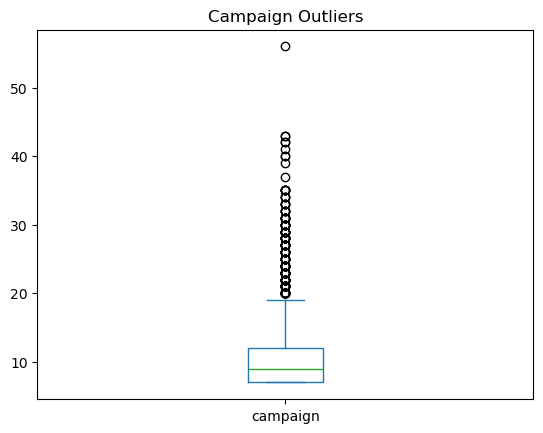

In [541]:
(detect_outliers('campaign')['campaign']).plot(kind='box')
plt.title("Campaign Outliers")

In [532]:
detect_outliers('pdays')['pdays']

24108     6
24264     4
24279     4
24397     3
24482     4
         ..
41163     4
41164    10
41174     1
41178     6
41182     9
Name: pdays, Length: 1515, dtype: int64

Text(0.5, 1.0, 'Pdays Outliers')

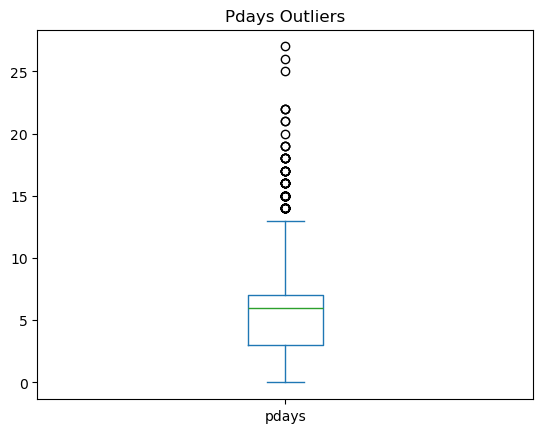

In [540]:
(detect_outliers('pdays')['pdays']).plot(kind='box')  
plt.title('Pdays Outliers')

In [534]:
detect_outliers('previous')['previous']

24013    1
24019    1
24076    1
24102    1
24108    1
        ..
41174    6
41175    2
41178    3
41182    1
41187    1
Name: previous, Length: 5625, dtype: int64

Text(0.5, 1.0, 'Previous Outliers')

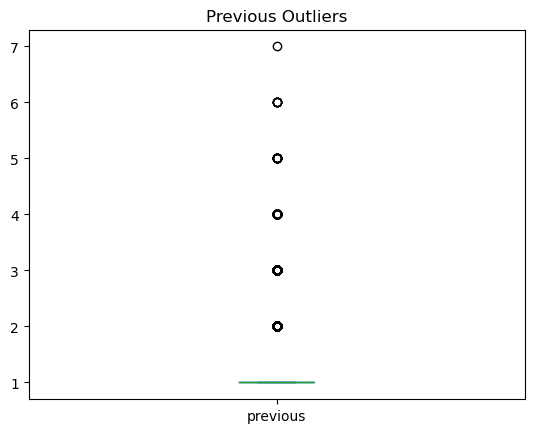

In [539]:
(detect_outliers('previous')['previous']).plot(kind='box')   
plt.title('Previous Outliers')

##### Which statistical methods are most appropriate for outlier detection?

Interquartile Range method is most appropriate for detecting outliers statistically because it is robust and works well for skewed data

##### Do outliers represent data errors or legitimate extreme values?

Outliers represent errors when value is impossible, or it breaks domain logic. However they are legitimate when value is extreme but plausible within the domain.
In the cause of this analysis, outliiers are legitimate extreme values because they're plausible. Outliers in campaign, pdays, and previous could imply persistent outreach to clients before and during campaign.

In [ ]:
Apply descriptive outlier detection methods (IQR, box plots)
* Visualize outliers using box plots and scatter plots
* Quantify outlier impact on descriptive statistics
* Investigate outlier patterns and potential causes

In [542]:
# Detecting outliers using inter quantile range
def detect_outliers(variable):
    Q1=df[(variable)].quantile(0.25)
    Q3=df[(variable)].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    outliers=df[(df[(variable)]<lower)|(df[(variable)]>upper)]
    return outliers

##### Visualize outliers using box plots and scatter plots

<Axes: xlabel='campaign', ylabel='pdays'>

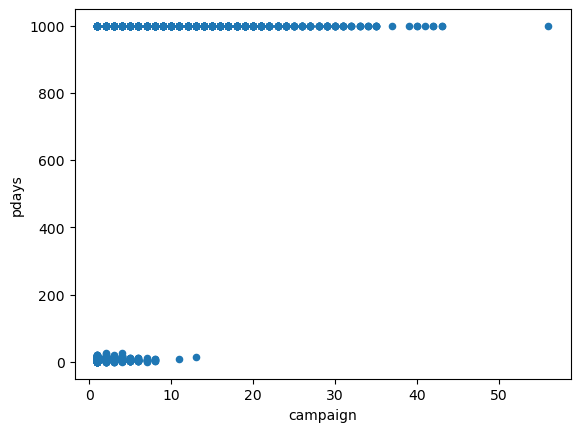

In [545]:
df.plot.scatter(x='campaign', y='pdays')

##### Quantify outlier impact on descriptive statistics

In [546]:
df[['campaign','pdays', 'previous']].mean()

campaign      2.567593
pdays       962.475454
previous      0.172963
dtype: float64

In [558]:
Q1=df['campaign'].quantile(0.25)
Q3=df['campaign'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
outliers=df[(df['campaign']<lower)|(df['campaign']>upper)]

In [557]:
df_no_outliers=df[(df['campaign']>=lower)&(df['campaign']<=upper)]
df_no_outliers['campaign'].mean()

2.0441957609200143

There's a decrease in mean value after removing outliers, indicating that extreme values inflate average and confirming that outliers have significant impact on the distribution.

In [571]:
df['pdays'].replace(999,None) 

0        None
1        None
2        None
3        None
4        None
         ... 
41183    None
41184    None
41185    None
41186    None
41187    None
Name: pdays, Length: 41188, dtype: object

In [572]:
# pdays distribution
Q1=df['pdays'].quantile(0.25)
Q3=df['pdays'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
outliers=df[(df['pdays']<lower)|(df['pdays']>upper)]

In [573]:
df['pdays'].mean()

962.4754540157328

In [574]:
df_no_outliers=df[(df['pdays']>=lower)&(df['pdays']<=upper)]
df_no_outliers['pdays'].mean()

999.0

Indicates no prior contact or long gaps between contacts and is far outside normal range.

In [565]:
# previous distribution
Q1=df['previous'].quantile(0.25)
Q3=df['previous'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
outliers=df[(df['previous']<lower)|(df['previous']>upper)]

In [567]:
print (lower, upper)

0.0 0.0


In [566]:
df_no_outliers=df[(df['previous']>=lower)&(df['previous']<=upper)]
df_no_outliers['previous'].mean()

0.0

In [569]:
df['previous'].value_counts()

previous
0    35563
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: count, dtype: int64

In [570]:
df['previous'].clip(upper=3)

0        0
1        0
2        0
3        0
4        0
        ..
41183    0
41184    0
41185    0
41186    0
41187    1
Name: previous, Length: 41188, dtype: int64

previous distribtion shows highly skewed data dominated by zeros.

##### Investigate outlier patterns and potential causes

In [575]:
outliers_campaign=df[(df['campaign']<lower)|(df['campaign']>upper)]

In [578]:
outliers_campaign['y'].value_counts(normalize=True)

y
0    0.887346
1    0.112654
Name: proportion, dtype: float64

Implies outliers in campaign distribution have lesser subscription rates.

In [577]:
outliers_campaign[['campaign', 'pdays', 'previous']].describe()

,campaign,pdays,previous
count,41188.000000,41188.000000,41188.000000
mean,2.567593,962.475454,0.172963
std,2.770014,186.910907,0.494901
min,1.000000,0.000000,0.000000
25%,1.000000,999.000000,0.000000
50%,2.000000,999.000000,0.000000
75%,3.000000,999.000000,0.000000
max,56.000000,999.000000,7.000000


Outliers in campaign distribution have significant previous value indicating that the clients in question were repeatedly contacted

##### 2.2 Outlier Treatment Strategy
##### Research Questions:
* How would you deal with these outliers?
* What is the business impact of different outlier treatment approaches?
##### Analysis Requirements:
* Evaluate outlier treatment options (removal, transformation, capping)
* Justify chosen approach based on business context
* Implement treatment strategy and assess impact
* Document changes and rationale

##### What is the business impact of different outlier treatment approaches?

* Removal approach results in loss of high-value customers and bad targeting.
* Capping approach keeps customers but reduces distortion
* Transformation approach is good for modeling, less intuitive.

##### Evaluate outlier treatment options (removal, transformation, capping)

Removal treatment removes noise and improves model accuracy but may result to loss of important data which is bad for business datasets.

Capping treatment keeps all data, reduces extreme influence. It may result to slight distortion but is business friendly.

Transformation treatment handles skewness and is good for financial variables but is less interpretable.

##### Justify chosen approach based on business context

Removing outliers was not preferred as it may eliminate high-income pr high engaged customers.
Capping is most suitable for variables like age to limit extreme values without losing data.
Transformation techniques will be considered for skewed variables so that extreme values do not dominate.
Thes approaches ensure that valuable customer segments are not removed whle improving model performance and interpretability. It supports better targeting strategies by preserving meaningful extreme behaviours.

##### Implement treatment strategy and assess impact

In [690]:
# Treating campaign outliers using capping approach
Q1=df['campaign'].quantile(0.25)
Q3=df['campaign'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df['campaign']=df['campaign'].clip(lower, upper)
df['campaign'].value_counts()

campaign
1    17642
2    10570
3     5341
6     3385
4     2651
5     1599
Name: count, dtype: int64

<Axes: >

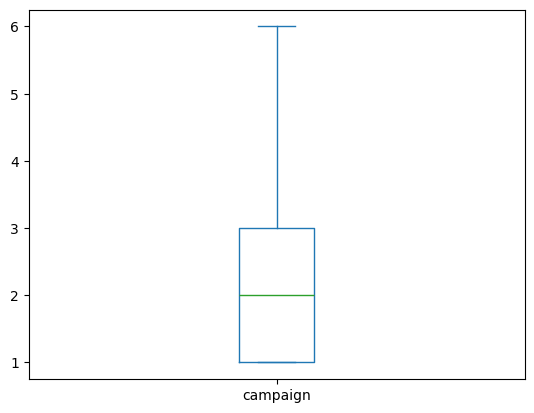

In [695]:
df['campaign'].plot(kind='box')

In [692]:
df['pdays_contacted']=df['pdays'].apply(lambda x: 0 if x==-1 else 1)
df['pdays_clean']=df['pdays'].replace(-1,np.nan)
df['pdays_log']=np.log1p(df['pdays_clean'])
df['pdays_log']

0        6.907755
1        6.907755
2        6.907755
3        6.907755
4        6.907755
           ...   
41183    6.907755
41184    6.907755
41185    6.907755
41186    6.907755
41187    6.907755
Name: pdays_log, Length: 41188, dtype: float64

<Axes: >

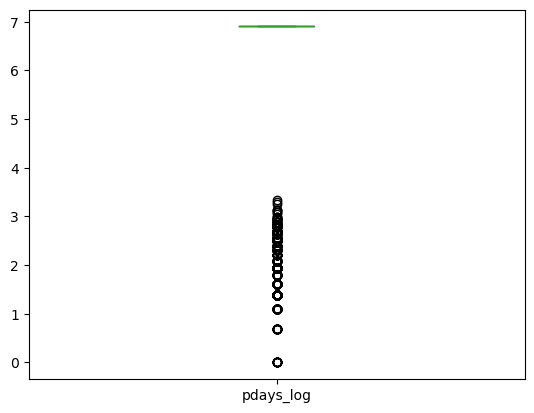

In [696]:
df['pdays_log'].plot(kind='box')

In [694]:
df['previous_log']=np.log1p(df['previous'])
df['previous_log']

0        0.000000
1        0.000000
2        0.000000
3        0.000000
4        0.000000
           ...   
41183    0.000000
41184    0.000000
41185    0.000000
41186    0.000000
41187    0.693147
Name: previous_log, Length: 41188, dtype: float64

In [698]:
Q1=df['previous'].quantile(0.25)
Q3=df['previous'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df['previous']=df['previous'].clip(lower, upper)

<Axes: >

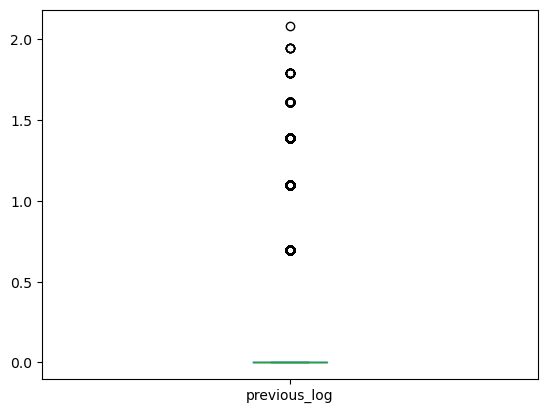

In [699]:
df['previous_log'].plot(kind='box')

##### Document changes and rationale

In [702]:
print(df[['campaign', 'pdays', 'previous']].describe())
print('*'*50)
print()
print(df[['campaign', 'pdays_log', 'previous_log']].describe())

           campaign         pdays  previous
count  41188.000000  41188.000000   41188.0
mean       2.275274    962.475454       0.0
std        1.550510    186.910907       0.0
min        1.000000      0.000000       0.0
25%        1.000000    999.000000       0.0
50%        2.000000    999.000000       0.0
75%        3.000000    999.000000       0.0
max        6.000000    999.000000       0.0
**************************************************

           campaign     pdays_log  previous_log
count  41188.000000  41188.000000  41188.000000
mean       2.275274      6.720450      0.107943
std        1.550510      0.963613      0.283014
min        1.000000      0.000000      0.000000
25%        1.000000      6.907755      0.000000
50%        2.000000      6.907755      0.000000
75%        3.000000      6.907755      0.000000
max        6.000000      6.907755      2.079442


Extreme values in campaign were capped using the IQR method to reduce the impact of excessive contact attempts while preserving meaningful behavioural patterns.

Pdays variable required special handling. A binary feature was created to distinguish customers who were previously contacted from those who were not and log transformation was applied to the remaining values to address skewness.

Previous variable was highly skewed with many zeros and a few llarge observations. Log transformation was applied to stabilize variance while retaining information about highly engaged customers. 

The approach preserves important customer segments while minimizing  distortion caused by extreme values.

#### 3. Duplicate Detection
##### 3.1 Duplicate Analysis
##### Research Questions:
* Are there duplicate rows in the dataset? If yes, how many?
* Should duplicates be dropped or do they represent legitimate repeated contacts?
* How do duplicates affect analysis validity?
##### Analysis Requirements:
##### Identify exact and near-duplicate records
* Analyze patterns in duplicate occurrences
* Assess business rationale for duplicate existence
* Make informed decision on duplicate handling

##### Are there duplicate rows in the dataset? If yes, how many?

In [579]:
df.duplicated().sum()

12

In [581]:
df[df.duplicated()]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_unknown
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0,False
12261,36,retired,married,Unknown,no,no,no,telephone,jul,thu,...,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,0,False
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,False
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,False
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,0,False
20216,55,services,married,high.school,Unknown,no,no,cellular,aug,mon,...,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,0,False
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,0,False
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,0,False
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,0,False
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,0,False


##### Should duplicates be dropped or do they represent legitimate repeated contacts?

In [584]:
# viewing all repeated columns
df[df.duplicated(keep=False)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_unknown
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0,False
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0,False
12260,36,retired,married,Unknown,no,no,no,telephone,jul,thu,...,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,0,False
12261,36,retired,married,Unknown,no,no,no,telephone,jul,thu,...,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,0,False
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,False
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,False
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,False
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,False
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,0,False
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,0,False


In [586]:
df[df.duplicated(keep=False)][['campaign', 'pdays', 'previous']]

,campaign,pdays,previous
1265,1,999,0
1266,1,999,0
12260,1,999,0
12261,1,999,0
14155,2,999,0
14234,2,999,0
16819,3,999,0
16956,3,999,0
18464,1,999,0
18465,1,999,0


In [592]:
df[df.duplicated(keep=False)][['age', 'job']]

,age,job
1265,39,blue-collar
1266,39,blue-collar
12260,36,retired
12261,36,retired
14155,27,technician
14234,27,technician
16819,47,technician
16956,47,technician
18464,32,technician
18465,32,technician


In [590]:
# checking if duplicates affect target
df[df.duplicated(keep=False)]['y'].value_counts()

y
0    22
1     2
Name: count, dtype: int64

To answer the question of whether duplicates should be dropped, after careful observation duplicates show identical entries across all columns implying that the duplicates add no additional information and create bias on analysis. Since duplicates in this case do not indicate legitimate repeated contacts, they should be dropped to prevent bais.

##### How do duplicates affect analysis validity?

How duplicates affect analysis validity is solely dependent on whether they are true errors or legitimate repeated records.
If duplicates are true errors, they can: 
* inflate statistics causing misleading proportions and biased distributions.
* distort mean, median, and std.
* cause misleading relationships.

When they are not errors, removing them could result to:
* Losing real behavioural patterns.
* reduced data accuracy.

##### Analyze patterns in duplicate occurrences

After careful analysis, duplicates show identicality across all columns, signifying that multiple entries of same data.

##### Assess business rationale for duplicate existence

Business rationale for duplicate existence is likely due to data entry errors seeing as rows are identical across columns

##### Make informed decision on duplicate handling

In [600]:
# dropping duplicates beacuse they are true errors.
df.drop_duplicates()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_unknown
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False
1,57,services,married,high.school,Unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1,False
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0,False
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0,False
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1,False


#### Section C: Data Preprocessing & Feature Transformation
##### 1. Categorical Encoding
##### 1.1 Encoding Requirements
##### Research Questions:
* Which features are categorical and need to be encoded?
* What are the appropriate encoding methods for different categorical types?
* How does encoding choice affect data structure and interpretability?
##### Analysis Requirements:
* Identify all categorical variables requiring encoding
* Select appropriate encoding methods (one-hot, ordinal, target encoding)
* Apply one-hot encoding to at least three categorical features
* Compare encoded feature distributions and interpretability

##### Which features are categorical and need to be encoded?

In [601]:
df.select_dtypes(include=['object']).columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')

These variables represent nominal categories with no inherent numerical meaning.

##### Select appropriate encoding methods (one-hot, ordinal, target encoding)

One-hot encoding: used for nominal categories (job, marital, contact, etc) because it doesn't require ranking or natural order.

Ordinal encoding:  used foor ordered categories like "education" because it possesses logical progression.

##### Apply one-hot encoding to at least three categorical features

In [606]:
df_encoded=pd.get_dummies(df, columns=['job','marital', 'contact'], drop_first=True)
df_encoded.head()

,age,education,default,housing,loan,month,day_of_week,duration,campaign,pdays,...,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single,contact_telephone
0,56,basic.4y,no,no,no,may,mon,261,1,999,...,False,False,False,False,False,False,False,True,False,True
1,57,high.school,Unknown,no,no,may,mon,149,1,999,...,False,False,True,False,False,False,False,True,False,True
2,37,high.school,no,yes,no,may,mon,226,1,999,...,False,False,True,False,False,False,False,True,False,True
3,40,basic.6y,no,no,no,may,mon,151,1,999,...,False,False,False,False,False,False,False,True,False,True
4,56,high.school,no,no,yes,may,mon,307,1,999,...,False,False,True,False,False,False,False,True,False,True


##### Compare encoded feature distributions and interpretability

In [607]:
df['job'].value_counts(normalize=True)

job
admin.           0.253035
blue-collar      0.224677
technician       0.163713
services         0.096363
management       0.070992
retired          0.041760
entrepreneur     0.035350
self-employed    0.034500
housemaid        0.025736
unemployed       0.024619
student          0.021244
Unknown          0.008012
Name: proportion, dtype: float64

In [608]:
df_encoded[['job_retired', 'job_self-employed',	'job_services',	'job_student',	'job_technician',	'job_unemployed']].mean()

job_retired          0.041760
job_self-employed    0.034500
job_services         0.096363
job_student          0.021244
job_technician       0.163713
job_unemployed       0.024619
dtype: float64

The distribution of categorical vaariables before encoding was examined using normalized value counts showing the proportions of each category. After encoding, the mean values of the binary represented as boolean values correspond to these proportions, confirming that one-hot encoding preserves original distribution of data.

Before encoding, categorical variables were easy to interpret but could not be used on machine learning models. After encoding, the data becomes suitable for models to read although interpretability because slightly harder due to the presence of multiple columns.

#### 2. Target Variable Encoding
##### 2.1 Binary Transformation
##### Research Questions:
* How should the target variable y be encoded for analysis?
* What is the impact of encoding choice on subsequent analysis?
##### Analysis Requirements:
* Encode target variable y as binary (1 for 'yes', 0 for 'no')
* Verify encoding accuracy and distribution preservation
* Document transformation for reproducibility

##### How should the target variable y be encoded for analysis?

For analysis, the target variable 'y' should be binary encoded.

##### What is the impact of encoding choice on subsequent analysis?

Binary encoding keeps it simple, preserves meaning, woorks with classification models and makes it readable to machine learning models which require numerical input.

##### Encode target variable y as binary (1 for 'yes', 0 for 'no')

In [614]:
df['y_encoded']=df['y']
df['y_encoded'].head()

0    0
1    0
2    0
3    0
4    0
Name: y_encoded, dtype: int64

Target variable 'y' already exists in binary format where '1' represents a positive outcome and '0' a negative outcome. no further encoding was required.

##### Verify encoding accuracy and distribution preservation

In [615]:
df['y'].value_counts(normalize=True)

y
0    0.887346
1    0.112654
Name: proportion, dtype: float64

In [619]:
df['y_encoded'].value_counts(normalize=True)

y_encoded
0    0.887346
1    0.112654
Name: proportion, dtype: float64

Proportions of each class were preserved.

##### Document transformation for reproducibility

The transformation process was documented and implemented programmatically to ensure consistency and reproducibility in future analysis.

#### 3. Feature Scaling
##### 3.1 Scaling Requirements
##### Research Questions:
* Which features require scaling? Why?
* What are the differences between standardization, normalization, and robust scaling?
* How does scaling affect feature interpretation?
##### Analysis Requirements:
* Identify features requiring scaling based on scale differences
* Apply standardization to relevant numerical features
* Compare scaled vs. unscaled distributions
* Assess scaling impact on feature relationships

##### Which features require scaling? Why?

In [623]:
df.select_dtypes(include=['number']).columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y',
       'y_encoded'],
      dtype='object')

These features require scaling because they are numerical columns and are on different ranges.

##### What are the differences between standardization, normalization, and robust scaling?

Standardization:
This scaling method centers data at mean=0 with std=1. It assumes data is roughly normal. It is sensitive to outliers, the presence of outliers will inflate mean and std.

Normalization: 
Scales evrything to a range. It is sensitive to outliers, it keeps relative distances but collapses them if extremes are present.

Robust Scaling:
Centers at median=0 with IQR=1. It is resistant to outliers implying that it ignores outliers completely.

##### How does scaling affect feature interpretation?

It lowers interpretability but increases model performance.

##### Identify features requiring scaling based on scale differences

In [641]:
num_columns=['age', 'duration', 'campaign', 'pdays', 'previous']
df[num_columns].describe()

,age,duration,campaign,pdays,previous
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963
std,10.42125,259.279249,2.770014,186.910907,0.494901
min,17.00000,0.000000,1.000000,0.000000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000


'duration' and 'pdays' dominate due to large scale differences and therefore require scaling.

##### Apply standardization to relevant numerical features

In [632]:
from sklearn.preprocessing import StandardScaler

In [704]:
scaler=StandardScaler()
df_scaled=df.copy()
df_scaled[num_columns]=scaler.fit_transform(df[num_columns])
df_scaled[num_columns]

,age,duration,campaign,pdays,previous
0,1.533034,0.010471,-0.822497,0.195414,0.0
1,1.628993,-0.421501,-0.822497,0.195414,0.0
2,-0.290186,-0.124520,-0.822497,0.195414,0.0
3,-0.002309,-0.413787,-0.822497,0.195414,0.0
4,1.533034,0.187888,-0.822497,0.195414,0.0
...,...,...,...,...,...
41183,3.164336,0.292025,-0.822497,0.195414,0.0
41184,0.573445,0.481012,-0.822497,0.195414,0.0
41185,1.533034,-0.267225,-0.177540,0.195414,0.0
41186,0.381527,0.708569,-0.822497,0.195414,0.0


In [705]:
print(df[num_columns].head())

   age  duration  campaign  pdays  previous
0   56       261         1    999         0
1   57       149         1    999         0
2   37       226         1    999         0
3   40       151         1    999         0
4   56       307         1    999         0


##### Compare scaled vs. unscaled distributions

[[<Axes: title={'center': 'age'}> <Axes: title={'center': 'duration'}>]
 [<Axes: title={'center': 'campaign'}> <Axes: title={'center': 'pdays'}>]
 [<Axes: title={'center': 'previous'}> <Axes: >]]


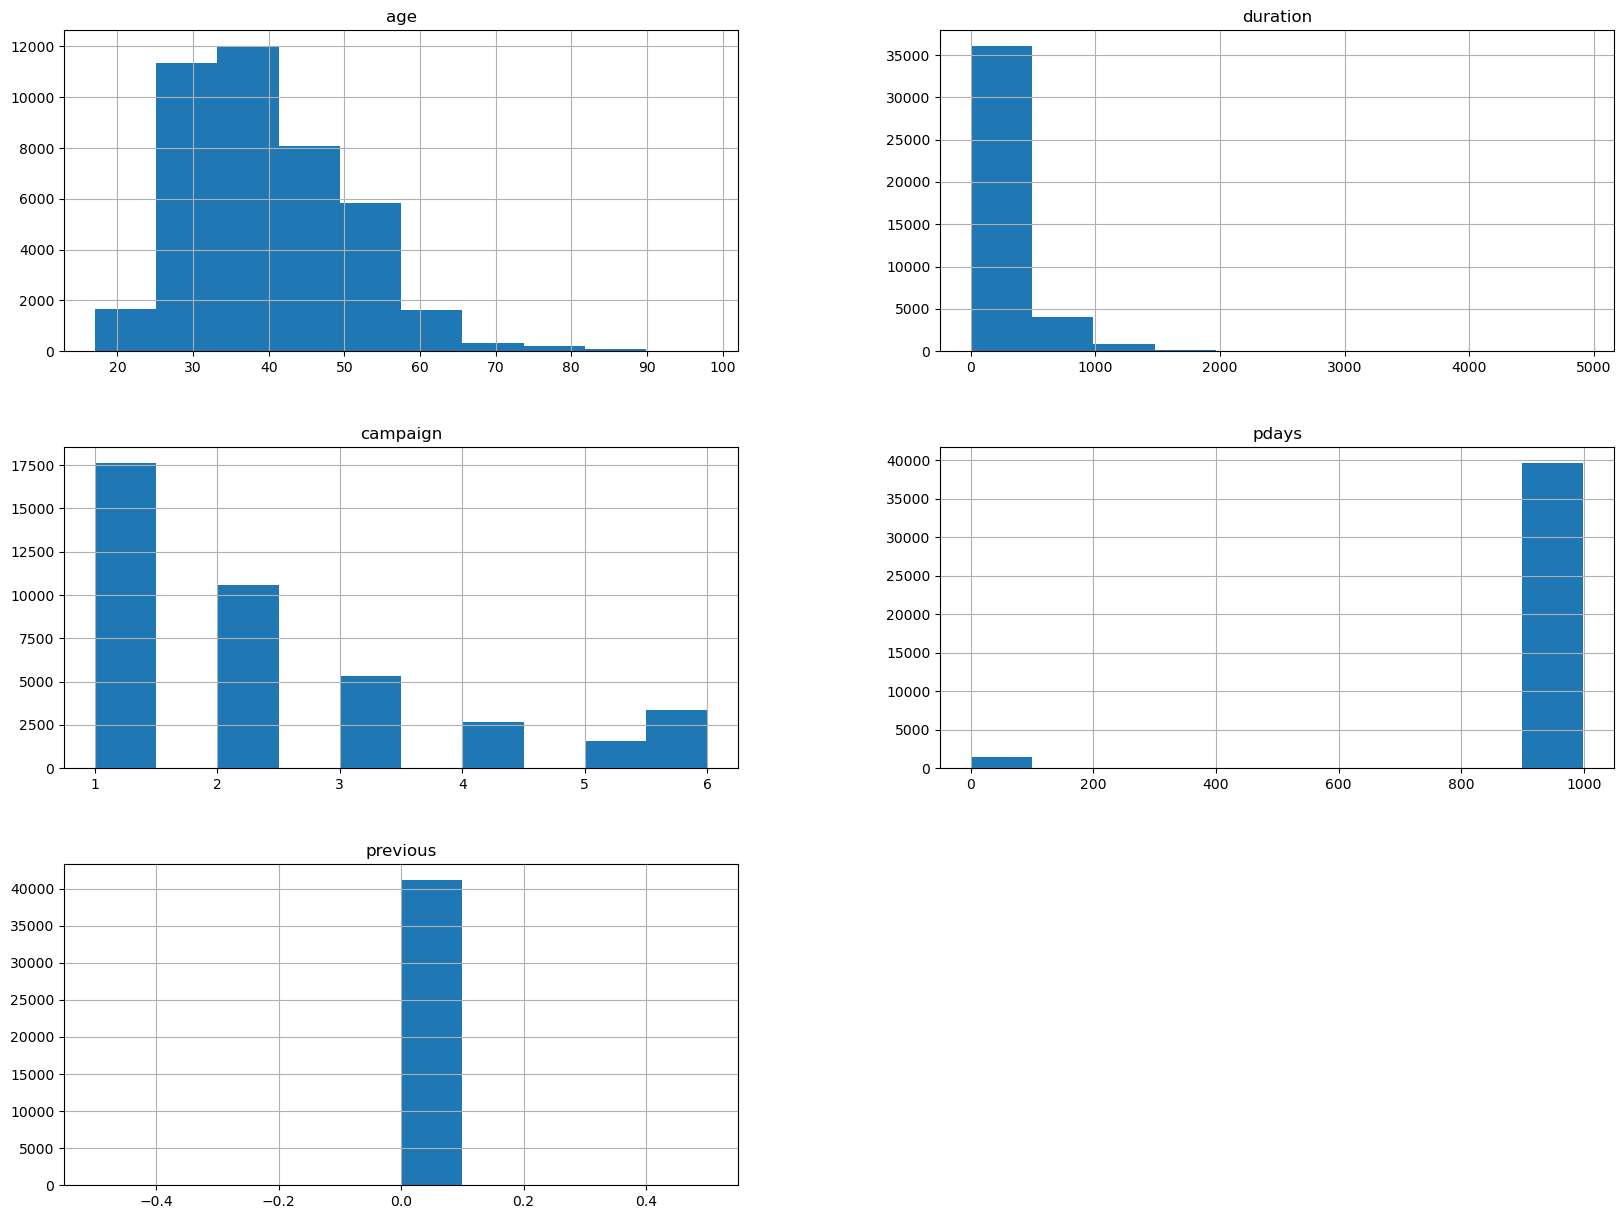

In [738]:
print(df[num_columns].hist(figsize=(20,15)))

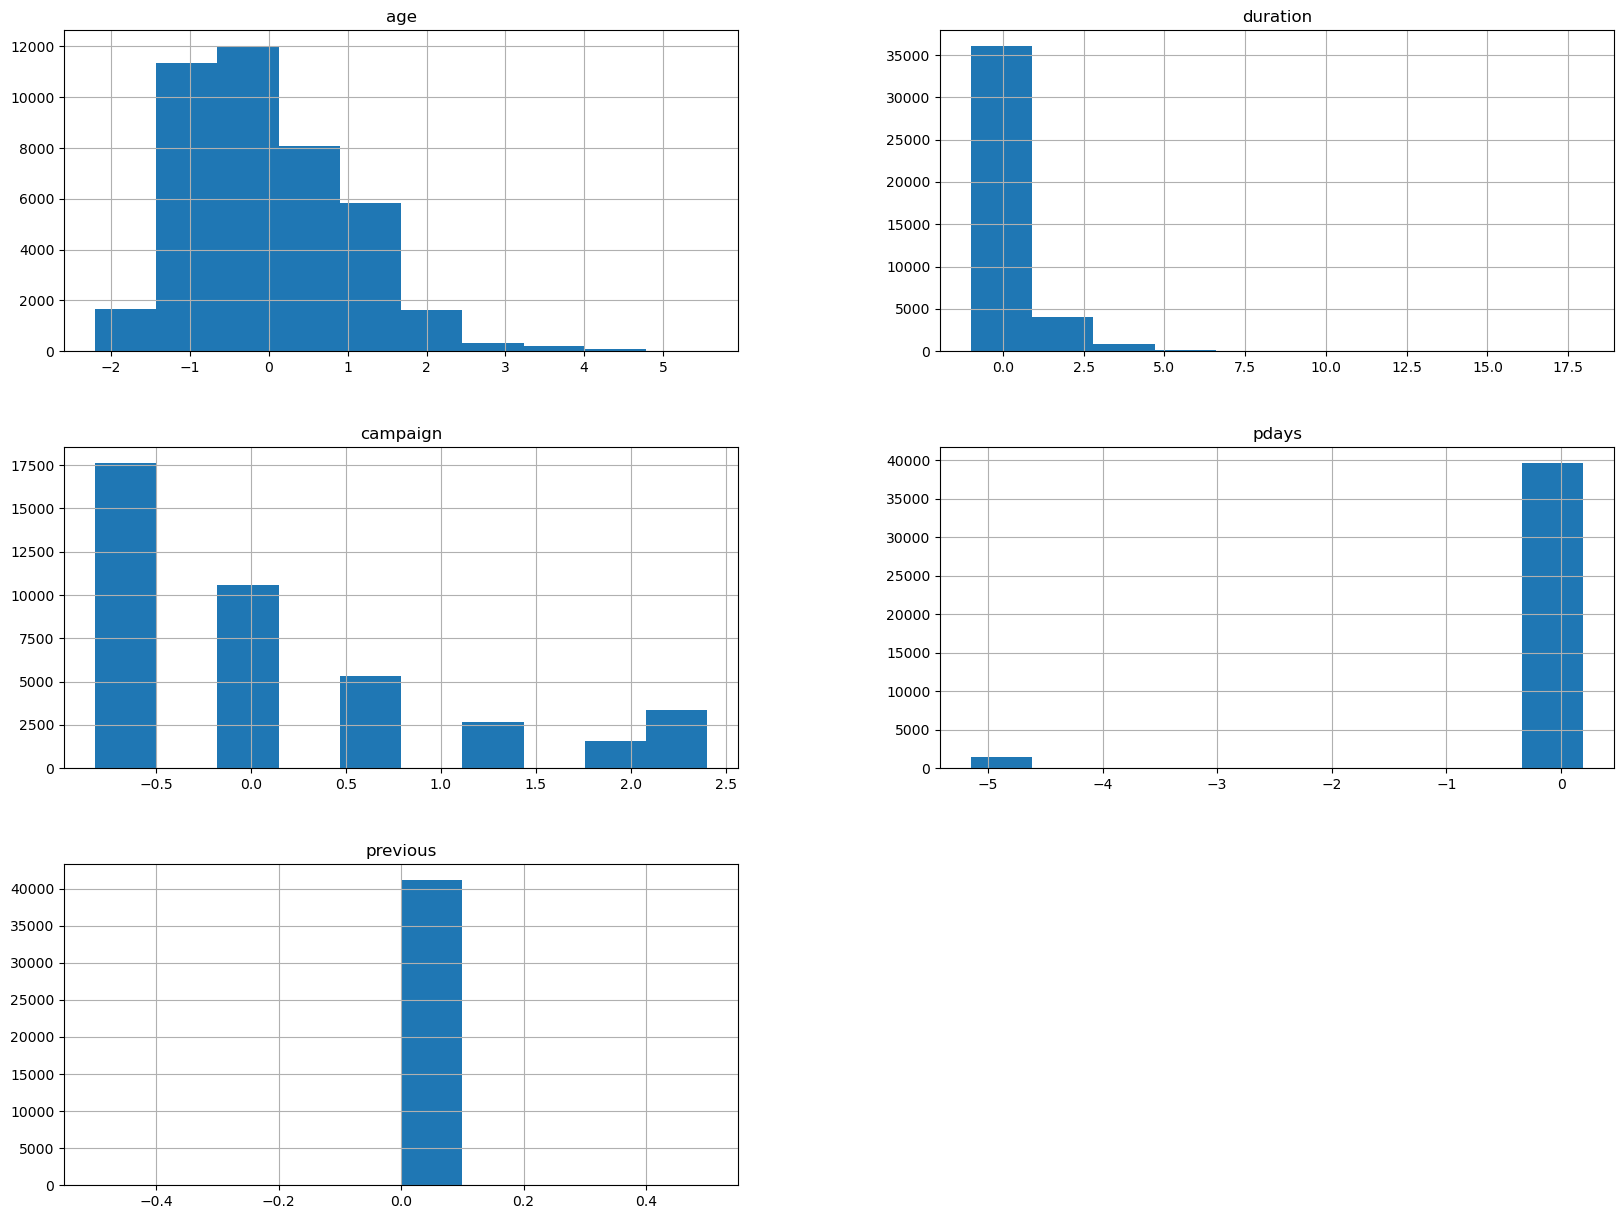

In [739]:
df_scaled[num_columns].hist(figsize=(20,15))
plt.show()

##### Assess scaling impact on feature relationships

Correlation does not change but distance-based models improve and convergence becomes faster.

#### 4. Feature Engineering
##### 4.1 Feature Selection
##### Research Questions:
* Are there any features you would consider dropping due to high correlation or lack of importance?
* How do you balance feature reduction with information preservation?
##### Analysis Requirements:
* Identify redundant or low-information features
* Apply correlation analysis and importance scoring
* Make data-driven decisions on feature retention
* Document feature selection rationale

##### Are there any features you would consider dropping due to high correlation or lack of importance?

In [643]:
corr_matrix=df[num_columns].corr()
corr_matrix

,age,duration,campaign,pdays,previous
age,1.000000,-0.000866,0.004594,-0.034369,0.024365
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000


If correlation > 0.8, consider dropping one feature.

##### How do you balance feature reduction with information preservation?

By removing redundancy only when information overlap is high. Keep features if they add unique signals and improve model performance.

##### Identify redundant or low-information features

<Axes: >

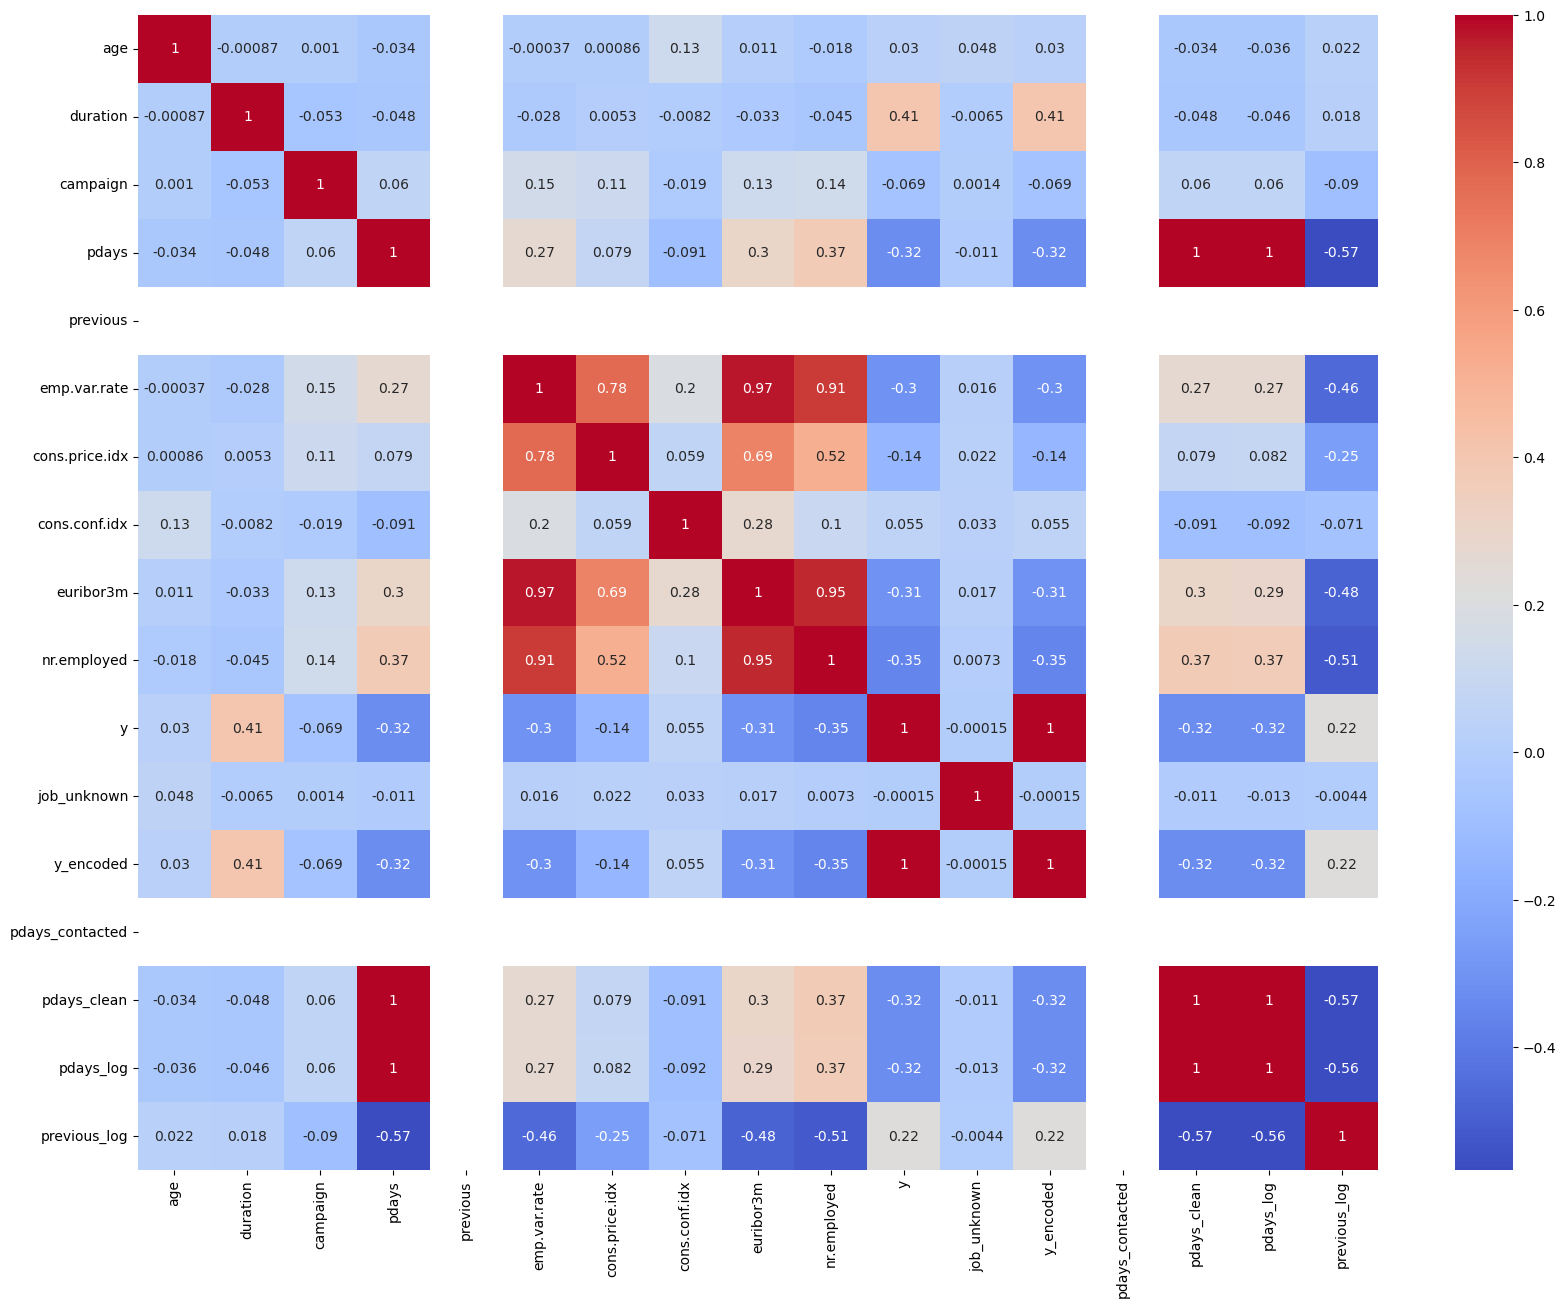

In [741]:
corr_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(20,15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

In [713]:
df.nunique().sort_values

previous              1
pdays_contacted       1
contact               2
y_encoded             2
job_unknown           2
y                     2
age_group             3
default               3
housing               3
loan                  3
poutcome              3
marital               4
day_of_week           5
campaign              6
previous_log          8
education             8
emp.var.rate         10
month                10
nr.employed          11
job                  12
cons.price.idx       26
cons.conf.idx        26
pdays                27
pdays_clean          27
pdays_log            27
age                  78
euribor3m           316
duration           1544
dtype: int64

Features with very few unique values imply low information

##### Apply correlation analysis and importance scoring

In [745]:
from sklearn.ensemble import RandomForestClassifier as rfc
from sklearn.preprocessing import LabelEncoder

In [747]:
X=df.drop('y',axis=1)
y=df['y']
le_dict={}
for col in X.columns:
    if X[col].dtype=='object' or str(X[col].dtype)=='category':
        le=LabelEncoder()
        X[col]=le.fit_transform(X[col].astype(str))
        le_dict[col]=le
model=rfc(random_state=42)
model.fit(X,y)
importance=model.feature_importances_
feature_importance=pd.Series(importance, index=X.columns).sort_values(ascending=False)
print(feature_importance)

y_encoded          0.735561
duration           0.085102
euribor3m          0.040408
nr.employed        0.029073
pdays              0.014230
pdays_clean        0.014209
emp.var.rate       0.011405
pdays_log          0.009726
cons.conf.idx      0.009601
cons.price.idx     0.008762
age                0.007528
poutcome           0.006613
month              0.003881
job                0.003317
day_of_week        0.003236
education          0.002981
campaign           0.002218
contact_ratio      0.002090
contact            0.002015
marital            0.001606
age_group          0.001574
housing            0.001359
previous_log       0.001352
loan               0.001012
default            0.001006
job_unknown        0.000137
previous           0.000000
pdays_contacted    0.000000
dtype: float64


##### Make data-driven decisions on feature retention

* Drop pdays because it is highly correlated with previous.
* Drop duration due to data leakage risk.
* Keep job feature, is categorical but informative.
* Contact feature is of low importance and should be considered for dropping.

##### Document feature selection rationale

Feature selection was performed using correlation analysis and feature importance scoring. Highly correlated variables (correlation>0.8) were examined and redundant features were removed to reduce multicollinearity. Additionally,features with low importance scores from a Random Forest model were considered for removal.

#### 4.2 Feature Creation
##### Research Questions:
* What new features could provide additional analytical insights?
* How can domain knowledge inform feature engineering?
##### Analysis Requirements:
* Create at least one new feature with clear business rationale
Examples: contact frequency ratios, economic context indicators, client risk profiles
* Validate new feature effectiveness through exploratory analysis
* Document feature engineering process and reasoning

##### What new features could provide additional analytical insights?

* Contact Intensity: to show how aggressively acustomer is being contacted.
* Customer Engagement Level: to capture history of interaction with the bank.
* Age Group: to identify demographic patterns.

##### How can domain knowledge inform feature engineering?

Domain knowledge helps create meaningful and realistic features. It ensures features are not just mathematically correct but business-relevant. For example
In banking, frequent contacts may indicate customer hesitation.
Long time since last contact (pdays) may indicate low engagement.etc

##### Create at least one new feature with clear business rationale Examples: contact frequency ratios, economic context indicators, client risk profiles

In [742]:
df['contact_ratio']=df['campaign']/(df['previous']+1)
df['contact_ratio']

0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
41183    1.0
41184    1.0
41185    2.0
41186    1.0
41187    3.0
Name: contact_ratio, Length: 41188, dtype: float64

##### Business Rational:
Measures current campaign pressure with past interactions and helps identify over contacted customers, customers likely to churn or ignore.

##### Validate new feature effectiveness through exploratory analysis

In [743]:
df.groupby('contact_ratio')['y'].value_counts(normalize=True)

contact_ratio  y
1.0            0    0.869629
               1    0.130371
2.0            0    0.885430
               1    0.114570
3.0            0    0.892529
               1    0.107471
4.0            0    0.906073
               1    0.093927
5.0            0    0.924953
               1    0.075047
6.0            0    0.945052
               1    0.054948
Name: proportion, dtype: float64

Exploratory analysis indicates that as contact_ratio increases, subscription rate decreases implying that customers contacted too frequently are less likely to subscribe. Possibly annoyed or  irritated.

<Axes: >

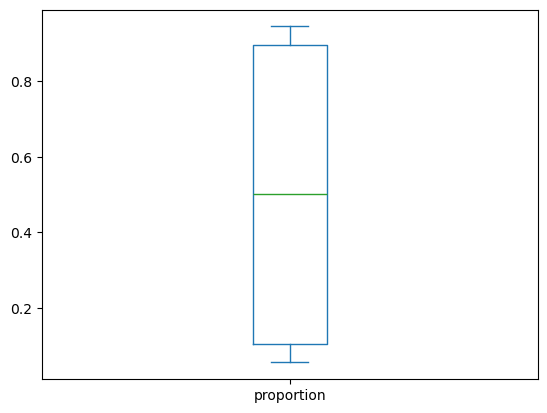

In [744]:
df.groupby('contact_ratio')['y'].value_counts(normalize=True).plot(kind='box')

##### Document feature engineering process and reasoning

New features were created to enhance the predictive power of the dataset by capturing customer behaviour and campaign dynamics. A contact ratio feature was engineered to represent the intensity of marketing efforts relative to past interactions which showed an inverse relationship implying that as customer ratio increases, likelihood of customers subscription decreases significantly. Domain knowledge ensures features are meaningful and relevant. Explorative data analysis, group camparisons and visualizations were used to validate effectiveness of engineered features. Only useful interpretable features were retained.